<a href="https://colab.research.google.com/github/pradeep-ramola/AI-ML/blob/main/ML-Projects/Reinforcement-Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gymnasium matplotlib numpy

Step 1 and 2: Define the RL Environment

In [ ]:
# Treasure Island environment
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
import gymnasium as gym
from gymnasium import spaces
import random

class TreasureIslandEnv(gym.Env):

    metadata = {"render_modes": ["human"]}

    def __init__(self, grid_size=5, seed=None):
        super().__init__()
        self.grid_size = grid_size
        self.n_states = grid_size * grid_size

        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Discrete(self.n_states)

        self.rewards = {
            "treasure": +10,
            "pearl": +5,
            "shark": -8,
            "rock": -3,
            "step": -1
        }

        self.treasure_pos = (grid_size - 1, grid_size - 1)
        self.pearl_positions = [(0, grid_size - 1), (grid_size - 1, 0)]
        self.shark_positions = [(1, 2), (2, 1)]
        self.rock_positions = [(2, 2), (1, 3)]

        self.current_tiles = {(0, 2): 1, (3, 0): 2}


        self.initial_state = (0, 0)
        self.state = None

        self.colors = {
            "empty": "#f0f8ff",
            "agent": "#1f77b4",
            "treasure": "#ffcc00",
            "pearl": "#e377c2",
            "shark": "#d62728",
            "rock": "#7f7f7f",
            "current": "#98df8a"
        }

        self.np_random, _ = gym.utils.seeding.np_random(seed)


    def _to_obs(self, pos):
        r, c = pos
        return r * self.grid_size + c

    def _from_obs(self, obs):
        r = obs // self.grid_size
        c = obs % self.grid_size
        return (r, c)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.np_random, _ = gym.utils.seeding.np_random(seed)


        self.pearl_positions = [(0, self.grid_size - 1), (self.grid_size - 1, 0)]

        self.state = self.initial_state
        return self._to_obs(self.state), {}

    def step(self, action):
        if action not in [0, 1, 2, 3]:
            raise ValueError(f"Invalid action {action}. Allowed: 0,1,2,3")

        r, c = self.state
        new_r, new_c = r, c

        if action == 0:      # Up
            new_r = r - 1
        elif action == 1:    # Down
            new_r = r + 1
        elif action == 2:    # Right
            new_c = c + 1
        elif action == 3:    # Left
            new_c = c - 1

        #Bounds
        if not (0 <= new_r < self.grid_size and 0 <= new_c < self.grid_size):
            reward = self.rewards["rock"]
            info = {"result": "hit_boundary"}
            return self._to_obs(self.state), reward, False, False, info

        self.state = (new_r, new_c)
        reward = 0
        terminated = False
        truncated = False
        info = {}

        if self.state == self.treasure_pos:
            reward = self.rewards["treasure"]
            terminated = True
            info["result"] = "found_treasure"
        elif self.state in self.pearl_positions:
            reward = self.rewards["pearl"]
            self.pearl_positions.remove(self.state)
            info["result"] = "found_pearl"
        elif self.state in self.shark_positions:
            reward = self.rewards["shark"]
            info["result"] = "bitten_by_shark"
        elif self.state in self.rock_positions:
            reward = self.rewards["rock"]
            info["result"] = "hit_rock"
        else:
            reward = self.rewards["step"]
            info["result"] = "moved"

        if (not terminated) and (self.state in self.current_tiles):
            push_dir = self.current_tiles[self.state]
            pr, pc = self.state
            # apply push
            if push_dir == 0: pr -= 1
            elif push_dir == 1: pr += 1
            elif push_dir == 2: pc += 1
            elif push_dir == 3: pc -= 1
            # bounds check push; if push moves out of bounds, you stay and get a small penalty
            if 0 <= pr < self.grid_size and 0 <= pc < self.grid_size:
                self.state = (pr, pc)

                if self.state == self.treasure_pos:
                    reward += self.rewards["treasure"]
                    terminated = True
                    info["result"] = "pushed_to_treasure"
                elif self.state in self.pearl_positions:
                    reward += self.rewards["pearl"]
                    info["result"] = "pushed_to_pearl"
                elif self.state in self.shark_positions:
                    reward += self.rewards["shark"]
                    info["result"] = "pushed_into_shark"
                elif self.state in self.rock_positions:
                    reward += self.rewards["rock"]
                    info["result"] = "pushed_into_rock"
                else:
                    info["current_push"] = True
            else:
                # blocked by sea boundary
                reward += self.rewards["rock"]
                info["current_push_blocked"] = True

        return self._to_obs(self.state), reward, terminated, truncated, info

    def render(self):
        gs = self.grid_size
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(0, gs)
        ax.set_ylim(0, gs)
        ax.set_xticks(range(gs + 1))
        ax.set_yticks(range(gs + 1))
        ax.set_aspect("equal")
        ax.grid(True)

        # Draw the tiles
        for i in range(gs):
            for j in range(gs):
                pos = (i, j)
                color = self.colors["empty"]
                if pos == self.treasure_pos:
                    color = self.colors["treasure"]
                elif pos in self.pearl_positions:
                    color = self.colors["pearl"]
                elif pos in self.shark_positions:
                    color = self.colors["shark"]
                elif pos in self.rock_positions:
                    color = self.colors["rock"]
                elif pos in self.current_tiles:
                    color = self.colors["current"]

                rect = Rectangle((j, i), 1, 1, facecolor=color, edgecolor="black")
                ax.add_patch(rect)

                if pos == self.treasure_pos:
                    ax.text(j + 0.5, i + 0.6, "T", ha="center", va="center", fontsize=12, weight="bold")
                elif pos in self.pearl_positions:
                    ax.text(j + 0.5, i + 0.6, "P", ha="center", va="center", fontsize=11)
                elif pos in self.shark_positions:
                    ax.text(j + 0.5, i + 0.6, "S", ha="center", va="center", fontsize=11)
                elif pos in self.rock_positions:
                    ax.text(j + 0.5, i + 0.6, "R", ha="center", va="center", fontsize=10)
                elif pos in self.current_tiles:
                    #showing arrow for current direction
                    d = self.current_tiles[pos]
                    arrow = {0: "↑", 1: "↓", 2: "→", 3: "←"}[d]
                    ax.text(j + 0.5, i + 0.6, arrow, ha="center", va="center", fontsize=12)

        # Draw agent
        ar, ac = self.state
        agent = Circle((ac + 0.5, ar + 0.5), 0.28, facecolor=self.colors["agent"])
        ax.add_patch(agent)

        ax.set_title("Treasure Island (T=treasure, P=pearl, S=shark, R=rock, arrows=current)")
        plt.gca().invert_yaxis()
        plt.show()

    def close(self):
        pass


Step 3: Run Random Agent for 10 Timesteps

Creating TreasureIslandEnv (unique environment)
Action space: Discrete(4)
Observation space: Discrete(25)
Total states (>=20): 25
Reward types: treasure, pearl, shark, rock, step

Initial state: (0, 0) (obs=0)


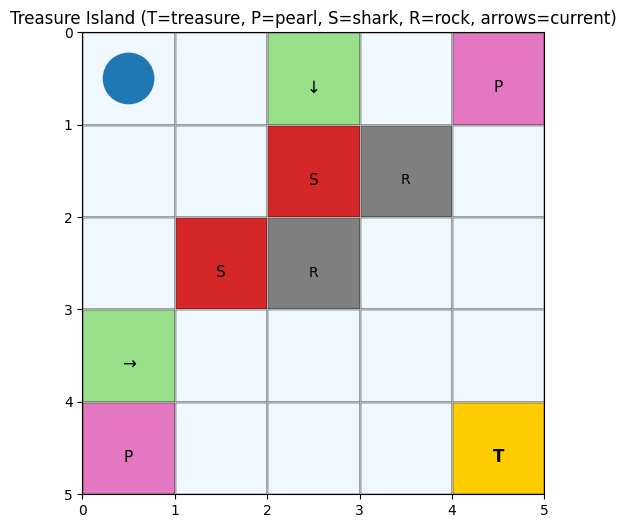


--- Timestep 1 ---
Current state: (0, 0)
Available actions: ['Down', 'Right']
Chosen action: Right
Next state: (0, 1)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


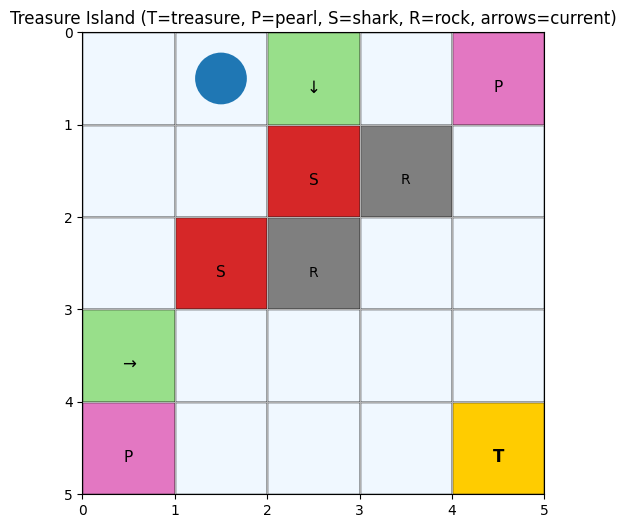


--- Timestep 2 ---
Current state: (0, 1)
Available actions: ['Down', 'Right', 'Left']
Chosen action: Down
Next state: (1, 1)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


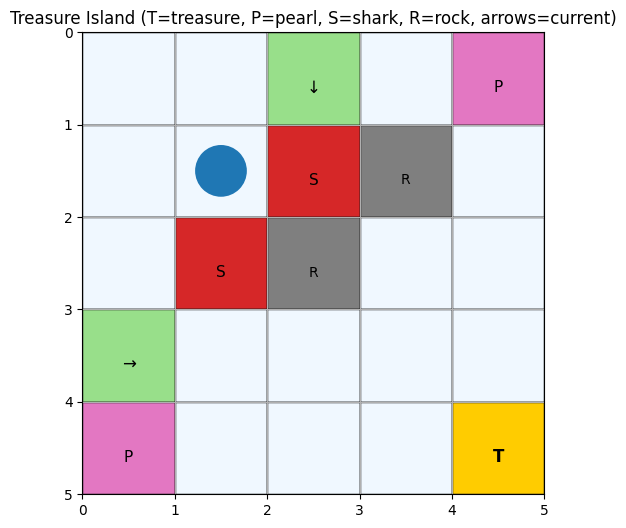


--- Timestep 3 ---
Current state: (1, 1)
Available actions: ['Up', 'Down', 'Right', 'Left']
Chosen action: Left
Next state: (1, 0)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


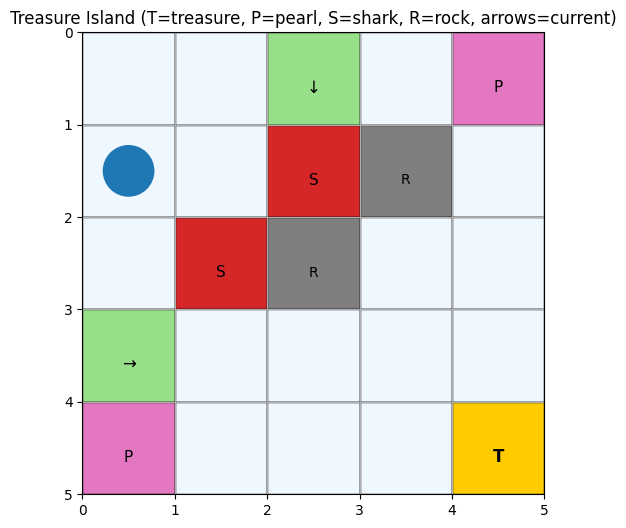


--- Timestep 4 ---
Current state: (1, 0)
Available actions: ['Up', 'Down', 'Right']
Chosen action: Up
Next state: (0, 0)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


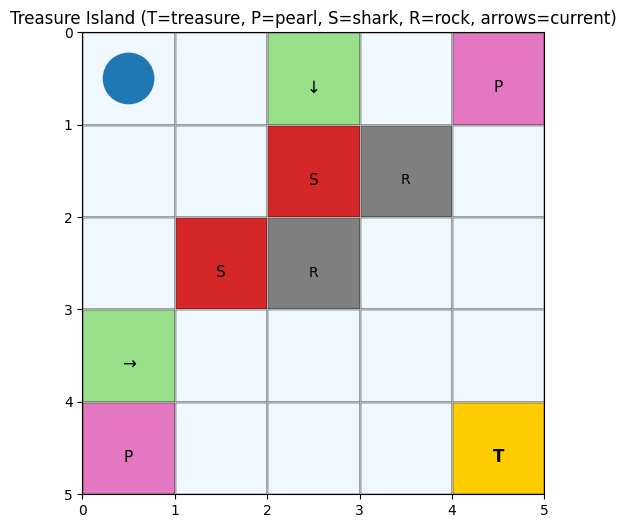


--- Timestep 5 ---
Current state: (0, 0)
Available actions: ['Down', 'Right']
Chosen action: Down
Next state: (1, 0)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


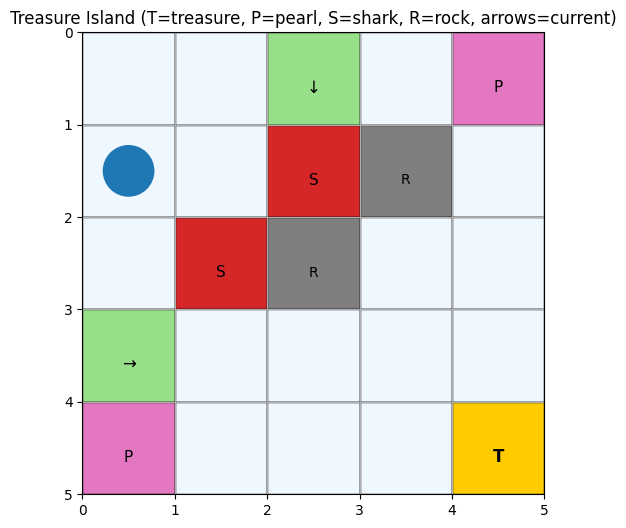


--- Timestep 6 ---
Current state: (1, 0)
Available actions: ['Up', 'Down', 'Right']
Chosen action: Down
Next state: (2, 0)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


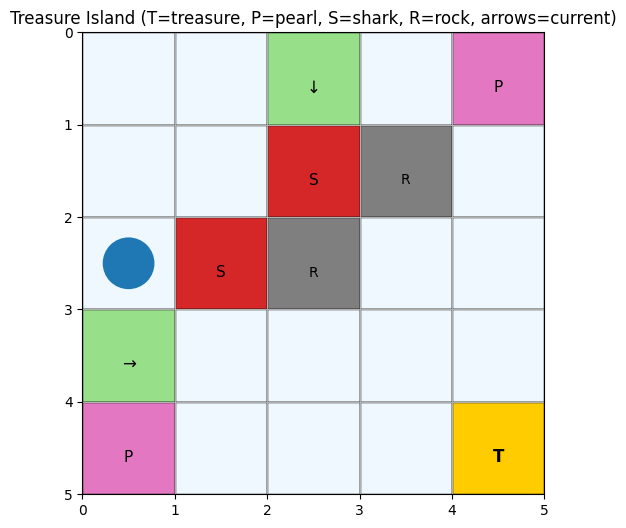


--- Timestep 7 ---
Current state: (2, 0)
Available actions: ['Up', 'Down', 'Right']
Chosen action: Up
Next state: (1, 0)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


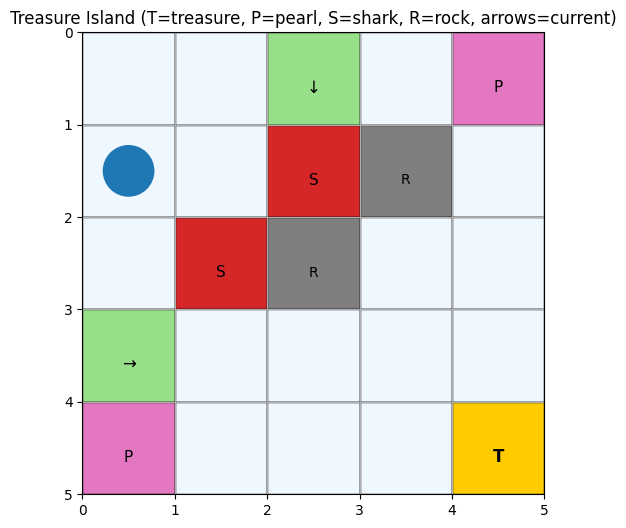


--- Timestep 8 ---
Current state: (1, 0)
Available actions: ['Up', 'Down', 'Right']
Chosen action: Up
Next state: (0, 0)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


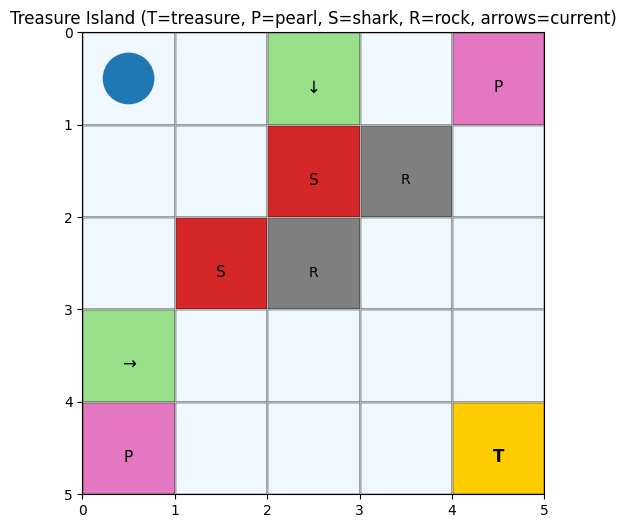


--- Timestep 9 ---
Current state: (0, 0)
Available actions: ['Down', 'Right']
Chosen action: Down
Next state: (1, 0)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


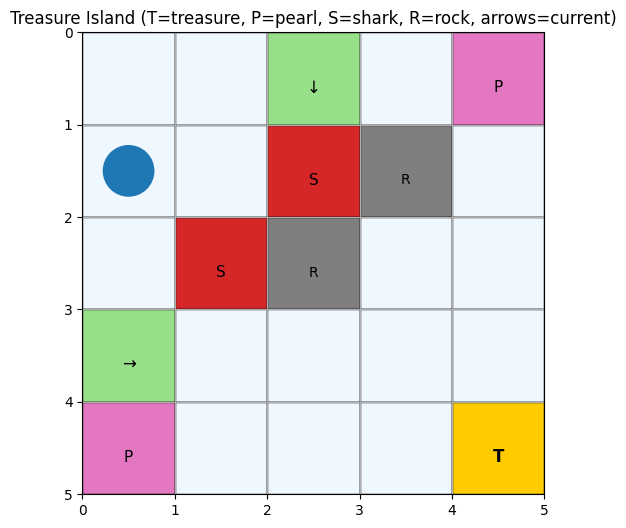


--- Timestep 10 ---
Current state: (1, 0)
Available actions: ['Up', 'Down', 'Right']
Chosen action: Up
Next state: (0, 0)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


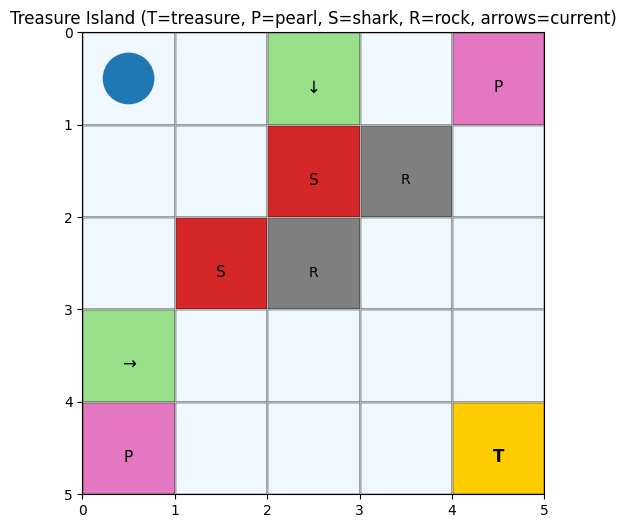


--- Timestep 11 ---
Current state: (0, 0)
Available actions: ['Down', 'Right']
Chosen action: Down
Next state: (1, 0)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


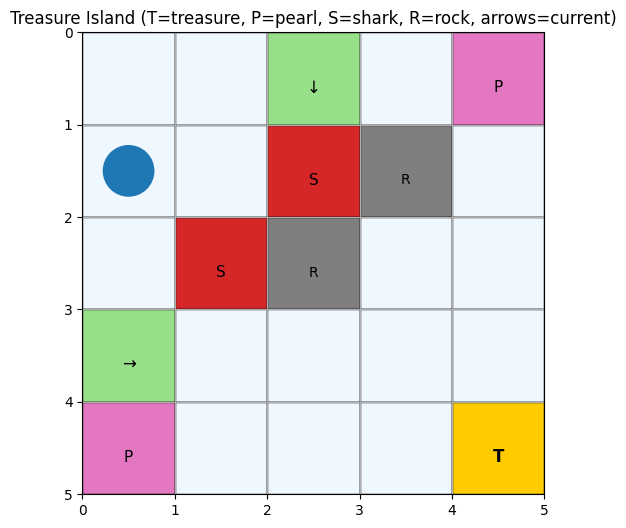


--- Timestep 12 ---
Current state: (1, 0)
Available actions: ['Up', 'Down', 'Right']
Chosen action: Right
Next state: (1, 1)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


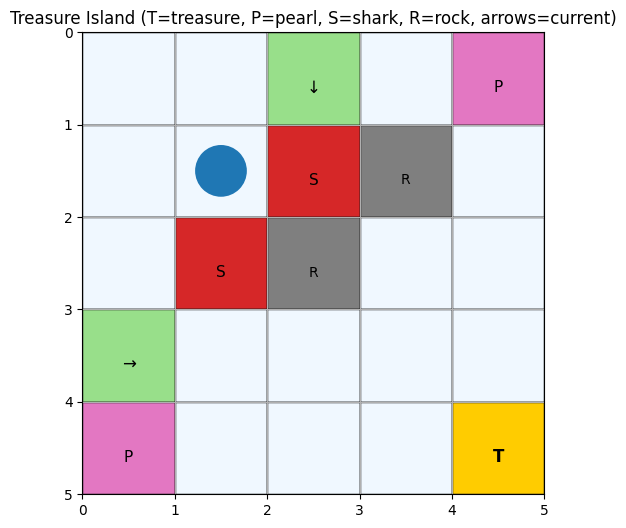


--- Timestep 13 ---
Current state: (1, 1)
Available actions: ['Up', 'Down', 'Right', 'Left']
Chosen action: Left
Next state: (1, 0)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


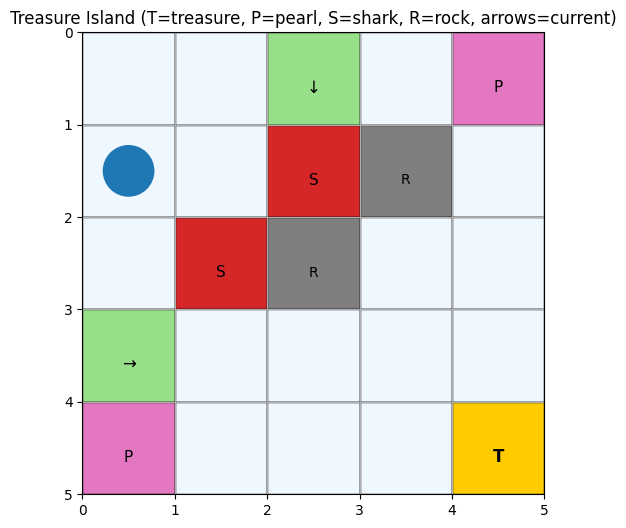


--- Timestep 14 ---
Current state: (1, 0)
Available actions: ['Up', 'Down', 'Right']
Chosen action: Up
Next state: (0, 0)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


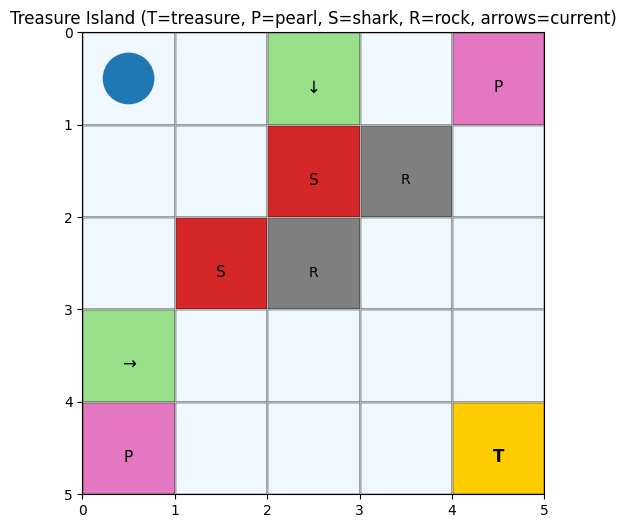


--- Timestep 15 ---
Current state: (0, 0)
Available actions: ['Down', 'Right']
Chosen action: Right
Next state: (0, 1)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


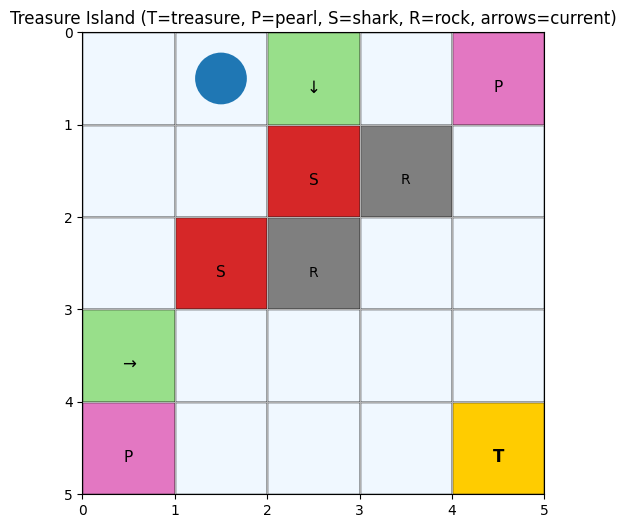


--- Timestep 16 ---
Current state: (0, 1)
Available actions: ['Down', 'Right', 'Left']
Chosen action: Right
Next state: (1, 2)
Reward: -9
Terminated: False
Info: {'result': 'pushed_into_shark'}


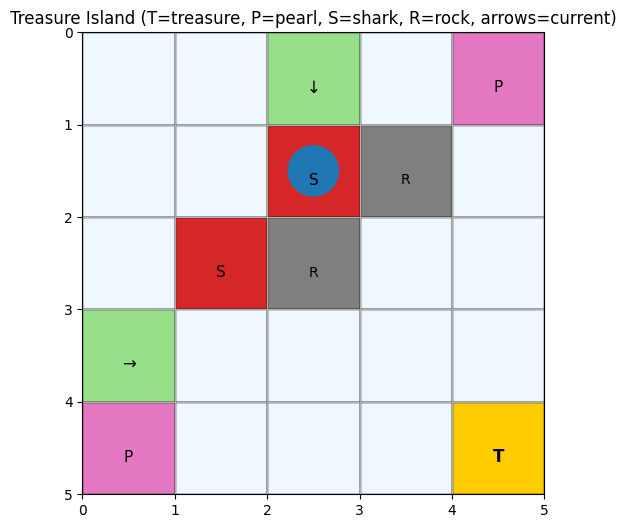


--- Timestep 17 ---
Current state: (1, 2)
Available actions: ['Up', 'Down', 'Right', 'Left']
Chosen action: Down
Next state: (2, 2)
Reward: -3
Terminated: False
Info: {'result': 'hit_rock'}


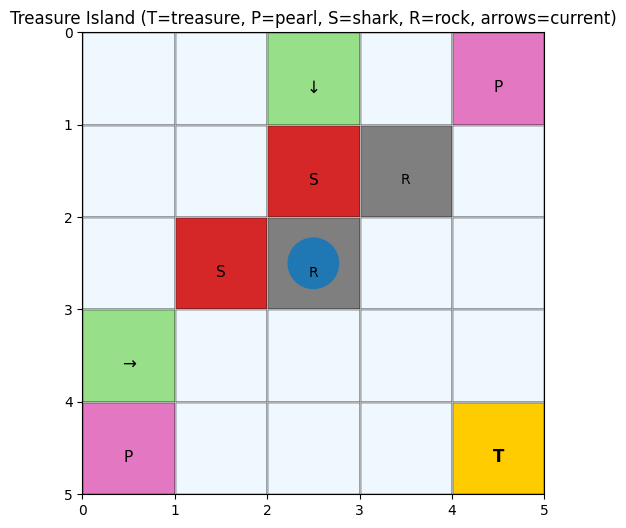


--- Timestep 18 ---
Current state: (2, 2)
Available actions: ['Up', 'Down', 'Right', 'Left']
Chosen action: Left
Next state: (2, 1)
Reward: -8
Terminated: False
Info: {'result': 'bitten_by_shark'}


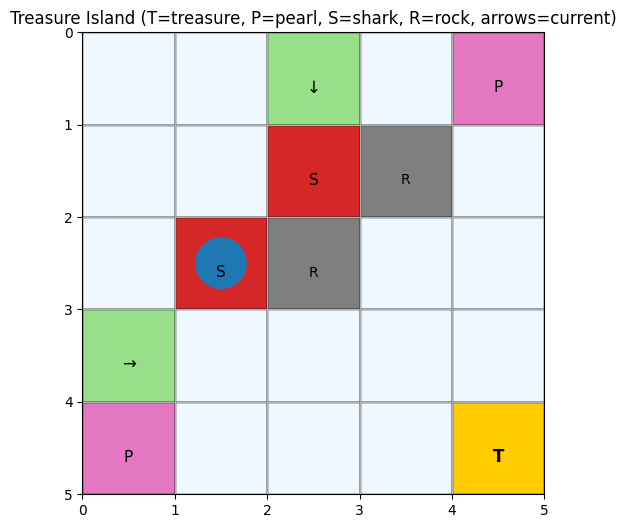


--- Timestep 19 ---
Current state: (2, 1)
Available actions: ['Up', 'Down', 'Right', 'Left']
Chosen action: Left
Next state: (2, 0)
Reward: -1
Terminated: False
Info: {'result': 'moved'}


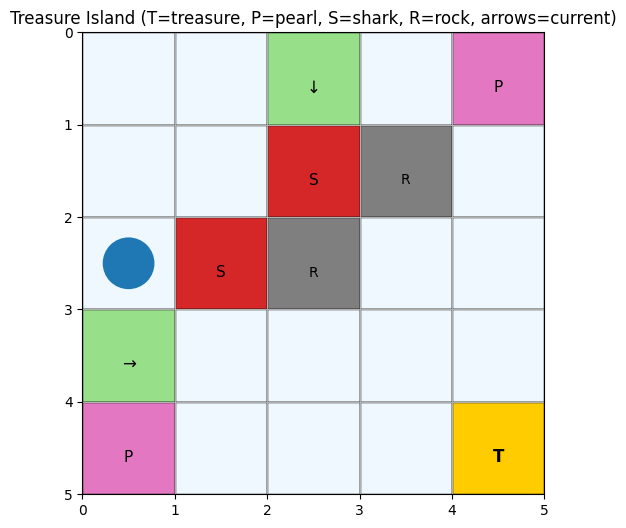


--- Timestep 20 ---
Current state: (2, 0)
Available actions: ['Up', 'Down', 'Right']
Chosen action: Down
Next state: (3, 1)
Reward: -1
Terminated: False
Info: {'result': 'moved', 'current_push': True}


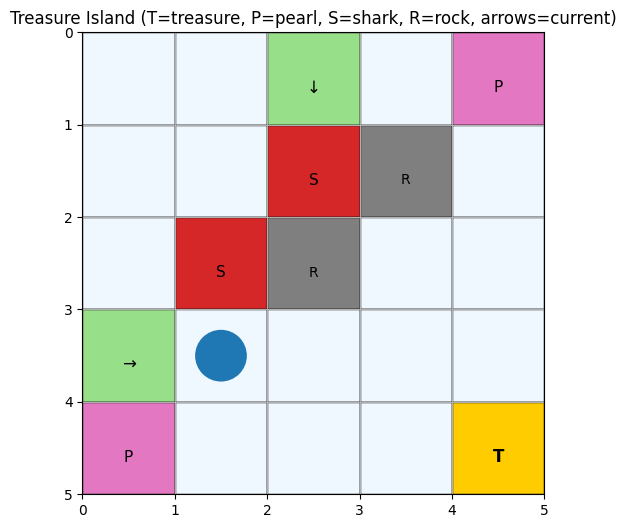


Test summary:
Timesteps run: 20
Total reward: -37
Final state: (3, 1)


In [ ]:
# Random agent test 10 steps
if __name__ == "__main__":
    print("Creating TreasureIslandEnv (unique environment)")
    env = TreasureIslandEnv(grid_size=5, seed=42)

    print(f"Action space: {env.action_space}")
    print(f"Observation space: {env.observation_space}")
    print(f"Total states (>=20): {env.n_states}")
    print("Reward types:", ", ".join(env.rewards.keys()))
    print()

    obs, _ = env.reset(seed=123)
    state = env._from_obs(obs)
    total_reward = 0
    action_map = {0: "Up", 1: "Down", 2: "Right", 3: "Left"}

    print(f"Initial state: {state} (obs={obs})")
    env.render()

    for t in range(20):
        print(f"\n--- Timestep {t+1} ---")

        r, c = state
        valid_actions = []
        if r > 0: valid_actions.append(0)
        if r < env.grid_size - 1: valid_actions.append(1)
        if c < env.grid_size - 1: valid_actions.append(2)
        if c > 0: valid_actions.append(3)

        action = random.choice(valid_actions)
        print("Current state:", state)
        print("Available actions:", [action_map[a] for a in valid_actions])
        print("Chosen action:", action_map[action])

        obs, reward, terminated, truncated, info = env.step(action)
        next_state = env._from_obs(obs)
        total_reward += reward

        print("Next state:", next_state)
        print("Reward:", reward)
        print("Terminated:", terminated)
        print("Info:", info)

        env.render()

        state = next_state
        if terminated:
            print("Treasure found!!!! episode complete.")
            break

    print("\nTest summary:")
    print("Timesteps run:", t + 1)
    print("Total reward:", total_reward)
    print("Final state:", state)

Step 4: Environment Description

Env name: Treasure Island Grid world

State Space:
The environment is a 5x5 grid, giving 25 discrete states, each represented as (row, col) where 0 <= row, col < 5

The observation returned to the agent is a single integer computed as
obs = row x 5 col

Action Space: The agent has 4 discrete actions:
  0 = up
  1 = Down
  2 = Right
  3 = Left

All actions that would move the agent out of the grid are blocked and treated as a "boundary hit".

Reward Structure:

Treasure, +10, Main goal, episode terminates
Pearl, +5, Positive reward collectible
Shark, -8, Dangerous tile
Rock, -3, Bad tile or boundary hit
Step, -1, Small regular movement penalty


Special Mechanic — Current Tiles

Some tiles contain a current (shown with a green arrow):

  When the agent lands on a current tile, it is pushed one extra step in the arrow's direction.

  If the push would leave the grid, the agent remains in place and receives a small penalty.

Aim:
The goal is to navigate from (0,0) to the treasure tile (4,4) while maximizing cumulative reward, avoiding sharks/rocks, and (optionally) collecting pearls.


Step 5: Environment Visualization

Step 5: Environment Visualisation
Visualization of Environment layout:


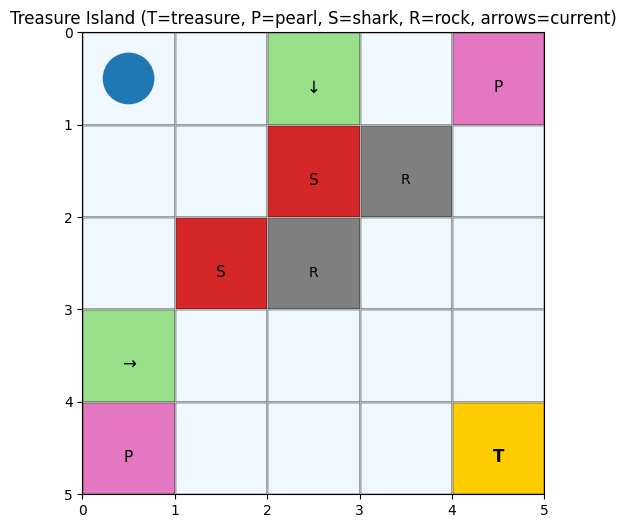

In [ ]:
print("Step 5: Environment Visualisation")
print("Visualization of Environment layout:")
env.reset()
env.render()

Step 6: Safety in AI Review

The environment has a bunch of safety measures baked in to keep things from going haywire. Every action the agent tries to take gets checked against what's actually allowed if it tries something illegal, that gets caught right away.
The agent can't accidentally wander off the grid either. If it tried to move out of bounds, It has to just stay put and take a small penalty for the attempt. Nice and controlled.

All the special tiles (treasure, pearls, sharks, rocks, currents) are explicitly defined in the code, so there's no ambiguity about what happens when you land on them. Everything's deterministic, which means no surprise behaviors or undefined edge cases.
Episodes end cleanly when the agent reaches the treasure, giving learning algorithms a clear stopping point. No hangups or infinite loops.
The deterministic rules, bounded state space and action validation all work together to keep the agent operating within a well defined, predictable environment. Nothing breaks, nothing goes off the rails.

# Part I Contribution Summary

| Step | Teammate | Contribution % |
|------|----------|----------------|
| Step 1, 2 and 3 (Env definition and implement)| Mohit Chaturvedi | 50% |
| Step 1, 2 and 3 (Env definition and implement)| Pradeep Ramola | 50% |
| Step 4, 5 and 6 (Description, Visualization and Review) | Mohit Chaturvedi | 50% |
| Step 4, 5 and 6 (Description, Visualization and Review) | Pradeep Ramola | 50% |

# Part 2


# Implement SARSA

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

def epsilon_greedy(Q, state, epsilon, nA):
    if np.random.rand() < epsilon:
        return np.random.randint(nA)
    else:
        max_q = np.max(Q[state])
        best_actions = np.where(Q[state] == max_q)[0]
        return np.random.choice(best_actions)


def sarsa(env, num_episodes=2000, max_steps=100, alpha=0.1, gamma=0.99,
          epsilon_start=1.0, epsilon_min=0.05, epsilon_decay=0.995):

    nS = env.n_states
    nA = env.action_space.n

    Q = np.zeros((nS, nA))

    rewards_per_episode = []
    eps_history = []
    epsilon = epsilon_start

    for ep in range(num_episodes):

        obs, info = env.reset()
        state = obs

        action = epsilon_greedy(Q, state, epsilon, nA)
        total_reward = 0

        for _ in range(max_steps):

            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = next_obs

            next_action = epsilon_greedy(Q, next_state, epsilon, nA)


            Q[state, action] += alpha * (
                reward + gamma * Q[next_state, next_action] - Q[state, action]
            )

            state, action = next_state, next_action
            total_reward += reward

            if terminated or truncated:
                break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        eps_history.append(epsilon)
        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode, eps_history


# Print initial Q-table & trained Q-table

In [ ]:
#init environment
Q_init = np.zeros((env.n_states, env.action_space.n))
print("Initial Q-table:\n", Q_init)




Initial Q-table:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [ ]:
Q, rewards, eps_hist = sarsa(env)

print("\nTrained Q-table:\n", Q)


Trained Q-table:
 [[ -1.34388953   3.10229282  -5.15707361  -2.18124933]
 [-14.30845325 -12.63664335 -16.14813759  -0.08747356]
 [  0.           0.           0.           0.        ]
 [ -5.64357137  -3.81192314  -0.88184161 -11.44916305]
 [ -6.11192975  -2.59320866  -6.30581072  -3.63501092]
 [ -1.70585764   3.63693562  -2.30500634   0.18640933]
 [-13.20274116 -14.92662856 -16.50045682   1.70080978]
 [-17.35343422 -10.40671315  -5.83308664 -11.80843731]
 [ -4.63604266  -4.20877798  -1.18460392 -14.7157372 ]
 [ -1.74058807   2.18645888  -5.0011249   -5.62793627]
 [  1.025702     5.57336667  -4.47443021   0.96104827]
 [ -9.93148926   5.35627901  -8.83563131  -8.96846073]
 [-17.03120406  -4.82565305  -4.22699786 -12.84262684]
 [ -6.98867866   2.01642687  -1.54633105  -7.8908532 ]
 [ -3.46909142   7.44714109  -2.26806266  -3.11784843]
 [  0.           0.           0.           0.        ]
 [ -4.1828952    6.5975083    4.31736551   4.59327476]
 [ -8.43461716   7.63599445   0.68220265  -5.8

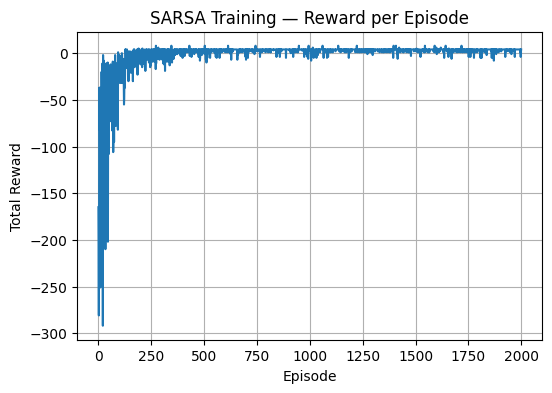

In [ ]:
#total rewards plot
plt.figure(figsize=(6,4))
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("SARSA Training — Reward per Episode")
plt.grid()
plt.show()


Plot: Epsilon decay

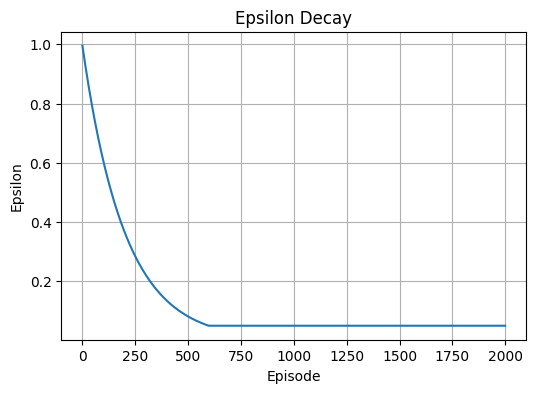

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(eps_hist)
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay")
plt.grid()
plt.show()


STEP 2(d) Greedy Policy Evaluation

In [ ]:
def run_greedy_policy(env, Q, episodes=10, max_steps=100):
    rewards_list = []

    for ep in range(episodes):
        obs, info = env.reset()
        state = obs
        total_reward = 0

        for _ in range(max_steps):

            action = np.argmax(Q[state])

            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = next_obs

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        rewards_list.append(total_reward)

    return rewards_list


In [ ]:
greedy_rewards = run_greedy_policy(env, Q)

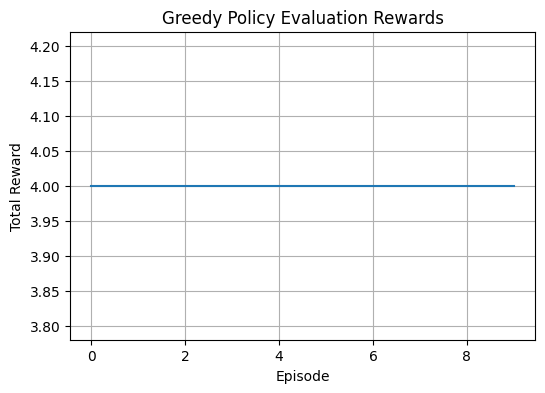

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(greedy_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Greedy Policy Evaluation Rewards")
plt.grid()
plt.show()

STEP 3  Hyperparameter Tuning

In [ ]:
gammas = [0.90, 0.95, 0.99]
decays = [0.99, 0.995, 0.999]

results = []

for g in gammas:
    for d in decays:
        Q_tmp, r_tmp, _ = sarsa(env, gamma=g, epsilon_decay=d)
        greedy_r = np.mean(run_greedy_policy(env, Q_tmp))

        results.append((g, d, greedy_r))
        print(f"gamma={g}, decay={d} avg greedy reward = {greedy_r}")


gamma=0.9, decay=0.99 avg greedy reward = 4.0
gamma=0.9, decay=0.995 avg greedy reward = 4.0
gamma=0.9, decay=0.999 avg greedy reward = 4.0
gamma=0.95, decay=0.99 avg greedy reward = 4.0
gamma=0.95, decay=0.995 avg greedy reward = 4.0
gamma=0.95, decay=0.999 avg greedy reward = 4.0
gamma=0.99, decay=0.99 avg greedy reward = 4.0
gamma=0.99, decay=0.995 avg greedy reward = 4.0
gamma=0.99, decay=0.999 avg greedy reward = 4.0


Selecting Best Hyperparameters

In [ ]:
best_gamma, best_decay, best_score = max(results, key=lambda x: x[2])
print("Best hyperparameters:")
print("gamma:", best_gamma)
print("epsilon_decay:", best_decay)
print("avg greedy reward:", best_score)


Best hyperparameters:
gamma: 0.9
epsilon_decay: 0.99
avg greedy reward: 4.0


Even with the hyperparameter tuning we didn't see any major changes as we are getting the same reward for every gamma and decay combination [4] so its almost similar to the base model with no changes

In [ ]:
#training model with best hyperparameters
Q_best, rewards_best, eps_best = sarsa(
    env,
    gamma=best_gamma,
    epsilon_decay=best_decay,
    num_episodes=3000,
    alpha=0.1
)

print("Best-model Q-table:\n", Q_best)


Best-model Q-table:
 [[ -3.35783005   0.35116017  -3.55000393  -3.15071358]
 [ -7.3516939   -6.6651942  -12.3084002   -1.76548047]
 [  0.           0.           0.           0.        ]
 [ -2.48289029  -3.13100313  -2.11243418  -6.69326171]
 [ -3.46347795  -2.6244424   -4.70751369  -2.60064276]
 [ -1.49440731   1.56767241  -1.6006563   -2.25978476]
 [ -6.38291297 -10.25888751 -10.98868851  -0.09104922]
 [-11.45958091  -3.57383303  -5.03843226  -5.51972255]
 [ -2.45433016  -2.62338931  -2.39888991  -7.93201282]
 [ -1.55082973  -0.6237534   -3.81927005  -3.70543679]
 [ -0.51585388   2.01190853  -5.97997294  -1.01606857]
 [ -4.38059249   2.70310365  -4.62412312  -4.04252483]
 [ -9.18558827   3.82847342  -2.06681674  -7.3673157 ]
 [ -4.20310553   5.9052286   -1.39789914  -4.00029299]
 [ -0.87236664   7.90060732  -2.79810991  -2.72584779]
 [  0.           0.           0.           0.        ]
 [ -5.89412146   2.46167239   4.4278043    0.84995393]
 [  0.17323231   5.24726883   5.91121466   2

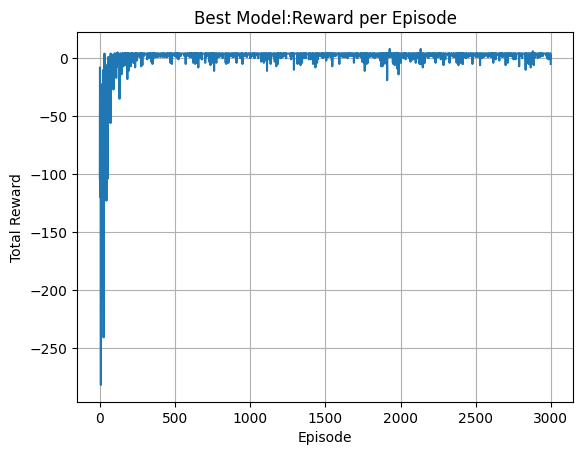

In [ ]:
#best setting
plt.plot(rewards_best)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Best Model:Reward per Episode")
plt.grid()
plt.show()


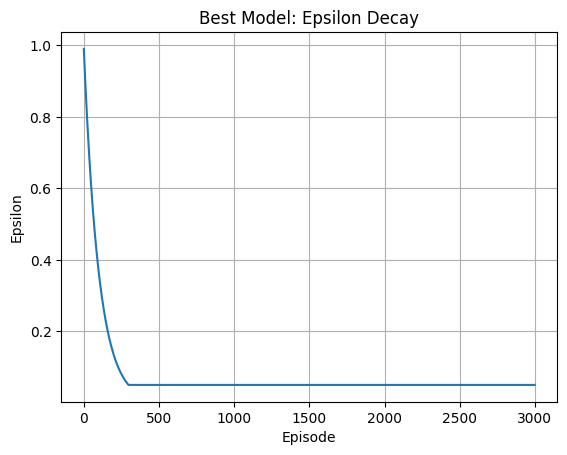

In [ ]:
#epsilon decay curve
plt.plot(eps_best)
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Best Model: Epsilon Decay")
plt.grid()
plt.show()


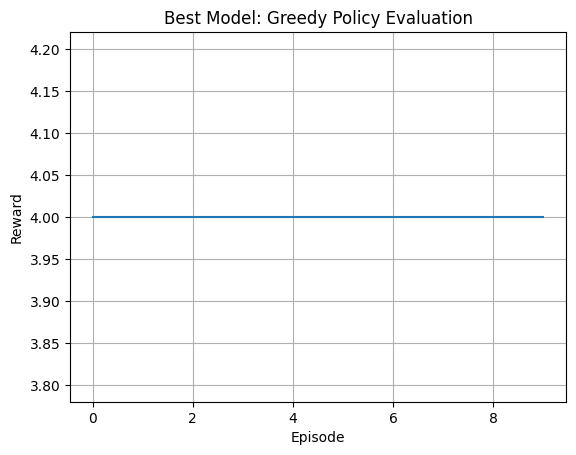

In [ ]:
#Greedy evaluation for best model
greedy_best = run_greedy_policy(env, Q_best)
plt.plot(greedy_best)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Best Model: Greedy Policy Evaluation")
plt.grid()
plt.show()


# Part II Contribution Summary

| Step | Teammate | Contribution % |
|------|----------|----------------|
| Step 1, 2 and 3 (Algo, eval results and Hyperparameter tuning)| Mohit Chaturvedi | 50% |
| Step 1, 2 and 3 (Algo, eval results and Hyperparameter tuning)| Pradeep Ramola | 50% |
| Step 4, 5 and 6 (Description, Visualization and Review) | Mohit Chaturvedi | 50% |
| Step 4, 5 and 6 (Description, Visualization and Review) | Pradeep Ramola | 50% |

## PART 3: N-Step Double Q-Learning

In [ ]:
import random
from copy import deepcopy

def select_action_epsilon_greedy(q_table_1, q_table_2, current_state, eps, num_actions):
    if np.random.rand() < eps:
        return np.random.randint(num_actions)

    combined_q = q_table_1[current_state] + q_table_2[current_state]
    max_value = np.max(combined_q)
    optimal_actions = np.where(combined_q == max_value)[0]
    return np.random.choice(optimal_actions)

In [ ]:




def train_double_q_nstep(environment, step_size=3, total_episodes=1500,
                         episode_limit=100, learning_rate=0.1, discount_factor=0.99,
                         eps_initial=1.0, eps_final=0.05, eps_multiplier=0.995,
                         show_progress=False):



    num_states = environment.n_states
    num_actions = environment.action_space.n

    q_table_1 = np.zeros((num_states, num_actions))
    q_table_2 = np.zeros((num_states, num_actions))

    episode_rewards = []
    epsilon_values = []
    current_epsilon = eps_initial

    for ep in range(total_episodes):
        observation, _ = environment.reset()
        current_state = observation

        trajectory_states = [current_state]
        trajectory_actions = []
        trajectory_rewards = []


        for step_idx in range(episode_limit):
            selected_action = select_action_epsilon_greedy(
                q_table_1, q_table_2, current_state, current_epsilon, num_actions
            )
            next_observation, step_reward, is_done, is_truncated, info = environment.step(selected_action)

            trajectory_actions.append(selected_action)
            trajectory_rewards.append(step_reward)
            current_state = next_observation
            trajectory_states.append(current_state)

            if is_done or is_truncated:
                break

        episode_length = len(trajectory_rewards)
        total_episode_reward = sum(trajectory_rewards)


        for time_step in range(episode_length):
            n_step_return = 0.0

            for k in range(step_size):
                if time_step + k < episode_length:
                    n_step_return += (discount_factor ** k) * trajectory_rewards[time_step + k]
                else:
                    break


            should_bootstrap = (time_step + step_size) < episode_length

            if should_bootstrap:
                future_state = trajectory_states[time_step + step_size]


                if np.random.rand() < 0.5:
                    best_action = np.argmax(q_table_1[future_state])
                    n_step_return += (discount_factor ** step_size) * q_table_2[future_state, best_action]

                    state_t = trajectory_states[time_step]
                    action_t = trajectory_actions[time_step]
                    q_table_1[state_t, action_t] += learning_rate * (n_step_return - q_table_1[state_t, action_t])
                else:
                    best_action = np.argmax(q_table_2[future_state])
                    n_step_return += (discount_factor ** step_size) * q_table_1[future_state, best_action]

                    state_t = trajectory_states[time_step]
                    action_t = trajectory_actions[time_step]
                    q_table_2[state_t, action_t] += learning_rate * (n_step_return - q_table_2[state_t, action_t])
            else:

                state_t = trajectory_states[time_step]
                action_t = trajectory_actions[time_step]

                if np.random.rand() < 0.5:
                    q_table_1[state_t, action_t] += learning_rate * (n_step_return - q_table_1[state_t, action_t])
                else:
                    q_table_2[state_t, action_t] += learning_rate * (n_step_return - q_table_2[state_t, action_t])

        #epsilon and track metrics update
        current_epsilon = max(eps_final, current_epsilon * eps_multiplier)
        epsilon_values.append(current_epsilon)
        episode_rewards.append(total_episode_reward)

        if show_progress and (ep % max(1, total_episodes // 5) == 0):
            print(f"n={step_size} | Episode {ep}/{total_episodes} | "
                  f"Reward: {total_episode_reward:.2f} | Epsilon: {current_epsilon:.4f}")

    return q_table_1, q_table_2, episode_rewards, epsilon_values















In [ ]:
def evaluate_greedy_policy(environment, q_table_1, q_table_2,
                           num_episodes=10, episode_limit=100):
    evaluation_rewards = []
    combined_q = q_table_1 + q_table_2

    for eval_episode in range(num_episodes):
        observation, _ = environment.reset()
        current_state = observation
        episode_reward = 0

        for _ in range(episode_limit):
            best_action = np.argmax(combined_q[current_state])
            next_observation, step_reward, is_done, is_truncated, info = environment.step(best_action)
            episode_reward += step_reward
            current_state = next_observation

            if is_done or is_truncated:
                break

        evaluation_rewards.append(episode_reward)

    return evaluation_rewards

In [ ]:
#training

step_sizes_to_test = [1, 2, 3, 4, 5]
experiment_results = {}

#hyperparameters
EPISODES = 2000
MAX_STEPS = 500
ALPHA = 0.1
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.995

env = TreasureIslandEnv(grid_size=5, seed=42)

print("starting n step Double Q-learning ")
print()

for n_steps in step_sizes_to_test:
    print(f"\nTraining with n={n_steps}")
    print("--------------------")

    q1, q2, training_rewards, epsilon_history = train_double_q_nstep(
        env,
        step_size=n_steps,
        total_episodes=EPISODES,
        episode_limit=MAX_STEPS,
        learning_rate=ALPHA,
        discount_factor=GAMMA,
        eps_initial=EPSILON_START,
        eps_final=EPSILON_MIN,
        eps_multiplier=EPSILON_DECAY,
        show_progress=True
    )

    greedy_eval_rewards = evaluate_greedy_policy(env, q1, q2,
                                                  num_episodes=10,
                                                  episode_limit=MAX_STEPS)

    experiment_results[n_steps] = {
        "q_table_1": q1,
        "q_table_2": q2,
        "training_rewards": training_rewards,
        "epsilon_history": epsilon_history,
        "evaluation_rewards": greedy_eval_rewards
    }

    print(f"\n{'=-=' * 10} n={n_steps} Summary {'*' * 10}")
    print(f"Q1 state sums (first 10): {np.round(q1.sum(axis=1)[:10], 2)}")
    print(f"Q2 state sums (first 10): {np.round(q2.sum(axis=1)[:10], 2)}")
    print(f"Greedy evaluation rewards: {greedy_eval_rewards}")
    print(f"Average greedy reward: {np.mean(greedy_eval_rewards):.2f}")
    print("--------------------")



starting n step Double Q-learning 


Training with n=1
--------------------
n=1 | Episode 0/2000 | Reward: -156.00 | Epsilon: 0.9950
n=1 | Episode 400/2000 | Reward: 2.00 | Epsilon: 0.1340
n=1 | Episode 800/2000 | Reward: 4.00 | Epsilon: 0.0500
n=1 | Episode 1200/2000 | Reward: 4.00 | Epsilon: 0.0500
n=1 | Episode 1600/2000 | Reward: 4.00 | Epsilon: 0.0500

=-==-==-==-==-==-==-==-==-==-= n=1 Summary **********
Q1 state sums (first 10): [  1.69 -15.26   0.   -10.37  -6.71   9.1  -17.6  -17.77  -6.62  -1.55]
Q2 state sums (first 10): [  2.41 -15.41   0.    -9.48  -6.19   8.53 -16.91 -17.91  -6.24  -1.58]
Greedy evaluation rewards: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Average greedy reward: 4.00
--------------------

Training with n=2
--------------------
n=2 | Episode 0/2000 | Reward: -494.00 | Epsilon: 0.9950
n=2 | Episode 400/2000 | Reward: 4.00 | Epsilon: 0.1340
n=2 | Episode 800/2000 | Reward: 4.00 | Epsilon: 0.0500
n=2 | Episode 1200/2000 | Reward: 4.00 | Epsilon: 0.0500
n=2 | Episode 160

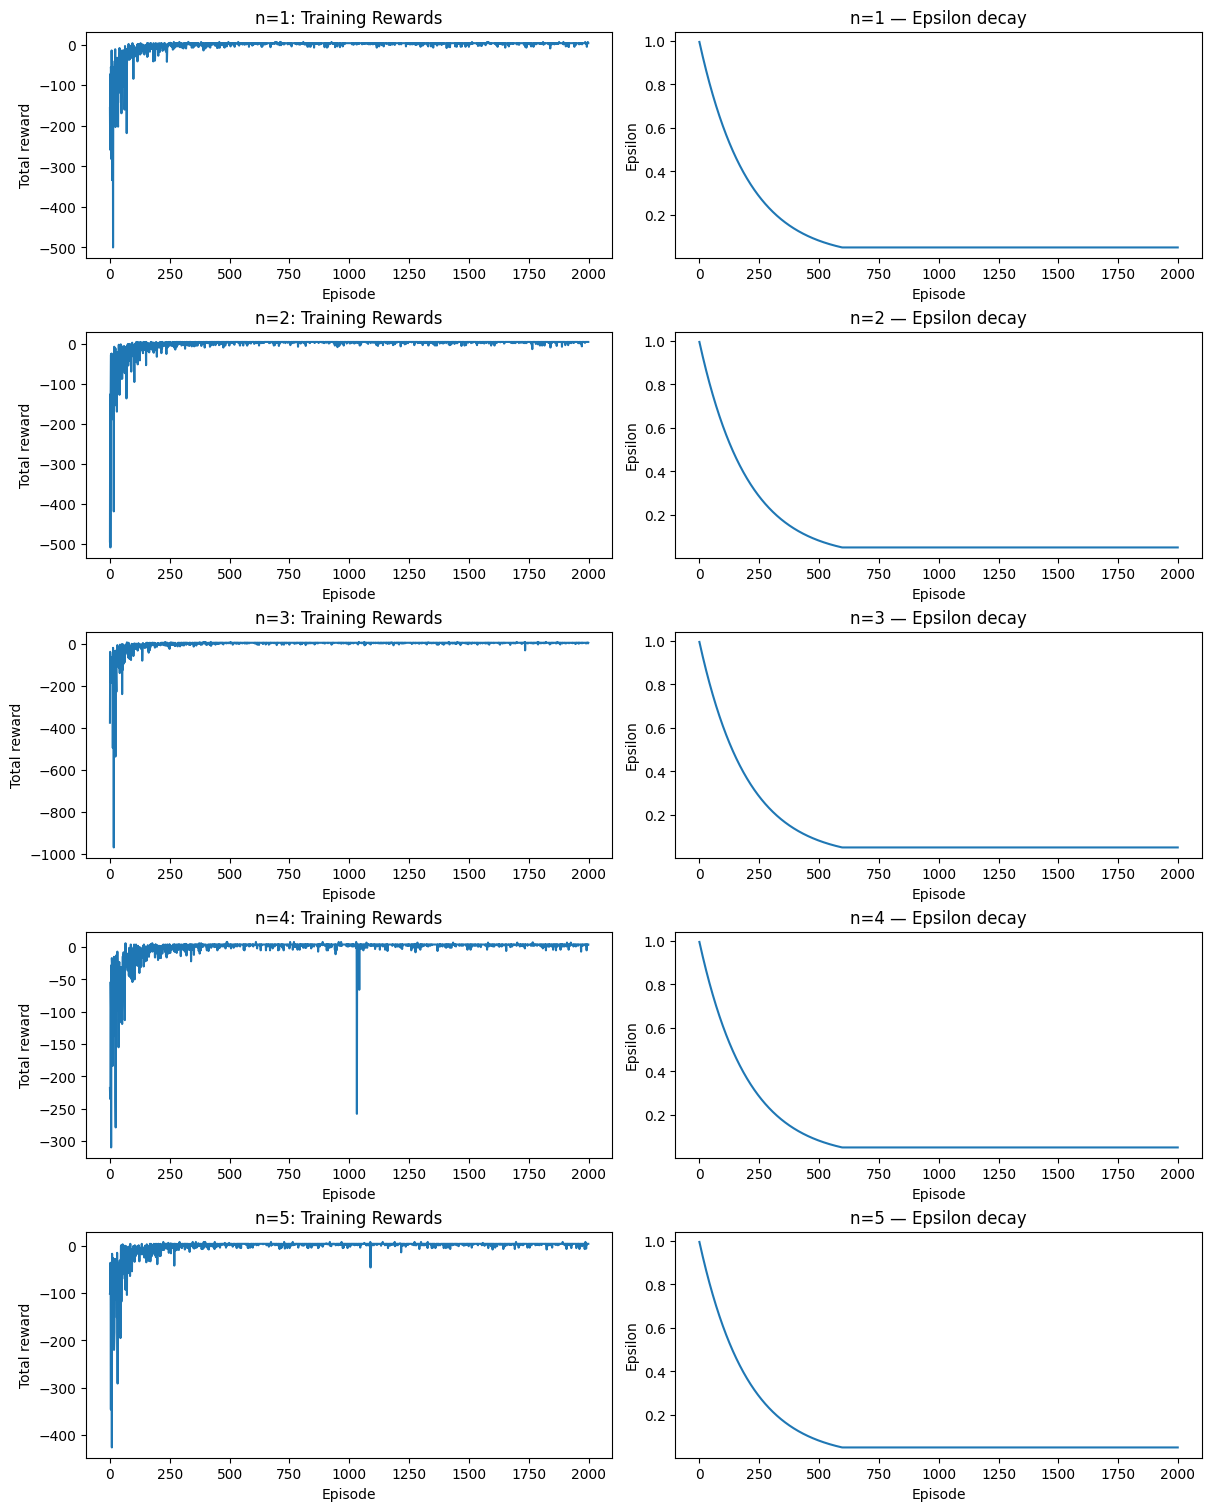

In [ ]:

#training progress and epsilon decay for each n
fig, axes = plt.subplots(len(step_sizes_to_test), 2,
                         figsize=(12, 3 * len(step_sizes_to_test)),
                         constrained_layout=True)

for idx, n_steps in enumerate(step_sizes_to_test):
    reward_axis = axes[idx, 0]
    epsilon_axis = axes[idx, 1]

    reward_axis.plot(experiment_results[n_steps]["training_rewards"])
    reward_axis.set_title(f"n={n_steps}: Training Rewards")
    reward_axis.set_xlabel("Episode")
    reward_axis.set_ylabel("Total reward")

    epsilon_axis.plot(experiment_results[n_steps]["epsilon_history"])
    epsilon_axis.set_title(f"n={n_steps} — Epsilon decay")
    epsilon_axis.set_xlabel("Episode")
    epsilon_axis.set_ylabel("Epsilon")

plt.show()

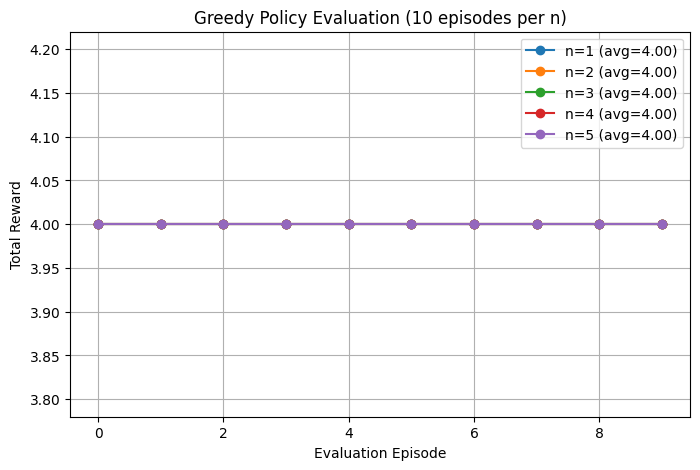

In [ ]:
#greedy evaluation
plt.figure(figsize=(8, 5))
for n_steps in step_sizes_to_test:
    eval_rewards = experiment_results[n_steps]["evaluation_rewards"]
    avg_reward = np.mean(eval_rewards)
    plt.plot(eval_rewards, label=f"n={n_steps} (avg={avg_reward:.2f})", marker='o')

plt.xlabel("Evaluation Episode")
plt.ylabel("Total Reward")
plt.title("Greedy Policy Evaluation (10 episodes per n)")
plt.legend()
plt.grid(True)
plt.show()

All of them are overlapping as the value is same for 1 to 5

In [ ]:
# BEST MODEL SELECTION

average_performances = {n: np.mean(experiment_results[n]["evaluation_rewards"])
                        for n in step_sizes_to_test}
best_step_size = max(average_performances.items(), key=lambda x: x[1])[0]

print()
print("FINAL RESULTS")
print()
print(f"Average evaluation rewards by n: {average_performances}")
print(f"Best step size (n): {best_step_size}")


FINAL RESULTS

Average evaluation rewards by n: {1: np.float64(4.0), 2: np.float64(4.0), 3: np.float64(4.0), 4: np.float64(4.0), 5: np.float64(4.0)}
Best step size (n): 1


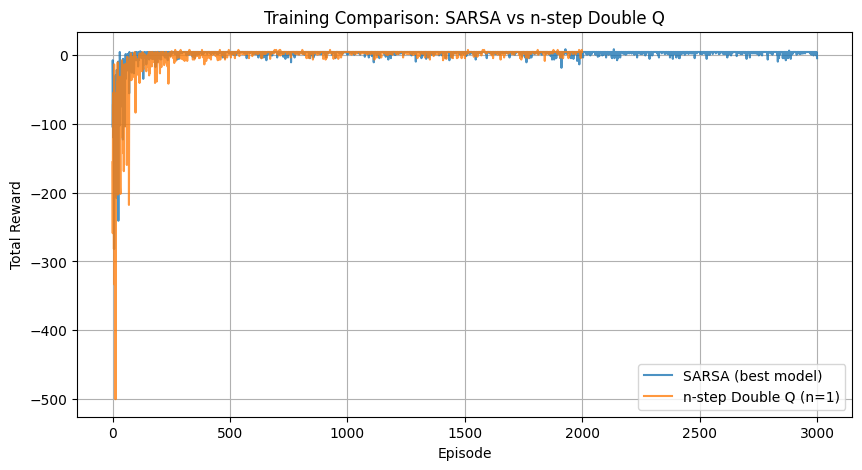

In [ ]:
# Compare with SARSA
plt.figure(figsize=(10, 5))

try:
    plt.plot(rewards_best, label="SARSA (best model)", alpha=0.8)
except NameError:
    if 'rewards' in globals():
        plt.plot(rewards, label="SARSA (original)", alpha=0.8)
    else:
        print("\nNote: SARSA reward history not found - skipping comparison")

plt.plot(experiment_results[best_step_size]["training_rewards"],
         label=f"n-step Double Q (n={best_step_size})", alpha=0.8)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Comparison: SARSA vs n-step Double Q")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Display final Q-tables
print()
print(f"FINAL Q-TABLES FOR BEST MODEL (n={best_step_size})")
print()
print(f"Q1 shape: {experiment_results[best_step_size]['q_table_1'].shape}")
print(f"Q2 shape: {experiment_results[best_step_size]['q_table_2'].shape}")
print(f"\nQ1 sample (first 8 states):")
print(np.round(experiment_results[best_step_size]['q_table_1'][:8], 3))
print(f"\nQ2 sample (first 8 states):")
print(np.round(experiment_results[best_step_size]['q_table_2'][:8], 3))

# Save results
double_q_results = deepcopy(experiment_results)



FINAL Q-TABLES FOR BEST MODEL (n=1)

Q1 shape: (25, 4)
Q2 shape: (25, 4)

Q1 sample (first 8 states):
[[-0.172  3.563 -1.755  0.055]
 [-4.494 -2.599 -9.644  1.476]
 [ 0.     0.     0.     0.   ]
 [-1.923 -1.716 -0.342 -6.39 ]
 [-2.764 -0.557 -2.661 -0.727]
 [ 1.798  4.609  1.452  1.238]
 [-2.969 -8.075 -9.563  3.004]
 [-8.855 -3.396 -3.032 -2.483]]

Q2 sample (first 8 states):
[[-0.219  3.563 -1.119  0.188]
 [-4.007 -2.897 -9.614  1.109]
 [ 0.     0.     0.     0.   ]
 [-1.869 -1.436  0.76  -6.932]
 [-2.465 -0.327 -2.717 -0.683]
 [ 2.069  4.609  0.738  1.111]
 [-3.163 -7.853 -9.247  3.353]
 [-9.529 -3.174 -3.378 -1.832]]


## Bonus


Environment & Visualization Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import gymnasium as gym
from gymnasium import spaces
import time
from IPython.display import clear_output


class Graphics:
    def __init__(self):

        self.colors = {
            'floor': np.array([[[240, 240, 240] for _ in range(10)] for _ in range(10)]),
            'shelf': np.zeros((10, 10, 3), dtype=int),
            'item': np.ones((10, 10, 3), dtype=int) * 255,
            'target': np.ones((10, 10, 3), dtype=int) * 255,
            'robot_idle': np.ones((10, 10, 3), dtype=int) * 255,
            'robot_carry': np.ones((10, 10, 3), dtype=int) * 255
        }


        self.colors['shelf'][:] = [139, 69, 19]
        self.colors['shelf'][2:3, :] = [100, 50, 10]
        self.colors['shelf'][6:7, :] = [100, 50, 10]


        self.colors['item'][2:8, 2:8] = [255, 215, 0]
        self.colors['item'][3:7, 3:7] = [255, 230, 50]

        self.colors['target'][:] = [220, 255, 220]
        self.colors['target'][4:6, 1:9] = [0, 200, 0]
        self.colors['target'][1:9, 4:6] = [0, 200, 0]


        self.colors['robot_idle'][1:9, 1:9] = [100, 149, 237] # Body
        self.colors['robot_idle'][2:4, 2:4] = [0, 0, 0] # Eyes
        self.colors['robot_idle'][2:4, 6:8] = [0, 0, 0]


        self.colors['robot_carry'][:] = self.colors['robot_idle'][:]
        self.colors['robot_carry'][4:8, 3:7] = [255, 215, 0]

In [ ]:



class WarehouseEnv(gym.Env):
    def __init__(self, grid_size=6):
        super().__init__()
        self.grid_size = grid_size
        self.n_actions = 6
        self.action_space = spaces.Discrete(6)


        #space size 6 * 6 * 2 = 72 states
        self.observation_space = spaces.Tuple((
            spaces.Discrete(grid_size),
            spaces.Discrete(grid_size),
            spaces.Discrete(2)
        ))
        self.FIXED_ITEM_POS = [0, 5]
        self.FIXED_DROP_POS = [5, 0]

        self.shelves = [
            (1, 1), (1, 2), (1, 3),
            (3, 2), (3, 3), (3, 4),
            (4, 2), (4, 3), (4, 4)
        ]

        self.gfx = Graphics()
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)


        self.robot_pos = self._get_random_free_cell()
        self.item_pos = self.FIXED_ITEM_POS
        self.drop_pos = self.FIXED_DROP_POS

        self.carrying = False
        self.picked_up_once = False
        self.steps = 0

        return self._get_obs(), {}

    def _get_random_free_cell(self, exclude=[]):
        while True:
            r = random.randint(0, self.grid_size - 1)
            c = random.randint(0, self.grid_size - 1)
            if (r, c) not in self.shelves and (r, c) not in exclude:
                return [r, c]

    def _get_obs(self):
        return (self.robot_pos[0], self.robot_pos[1], int(self.carrying))

    def step(self, action):
        self.steps += 1
        reward = -1
        terminated = False
        truncated = False

        r, c = self.robot_pos


        new_r, new_c = r, c
        if action == 0: new_r = max(0, r - 1) # Up
        elif action == 1: new_r = min(self.grid_size - 1, r + 1) # Down
        elif action == 2: new_c = max(0, c - 1) # Left
        elif action == 3: new_c = min(self.grid_size - 1, c + 1) # Right


        if (new_r, new_c) in self.shelves:
            reward += -20

        else:
            self.robot_pos = [new_r, new_c]


        if action == 4:
            if not self.carrying and self.robot_pos == self.item_pos:
                self.carrying = True
                if not self.picked_up_once:
                    reward += 25
                    self.picked_up_once = True
            else:
                reward += -5

        elif action == 5:
            if self.carrying and self.robot_pos == self.drop_pos:
                reward += 100
                terminated = True
                self.carrying = False
            else:
                reward += -5

        if self.steps >= 200:
            truncated = True

        return self._get_obs(), reward, terminated, truncated, {}

    def render(self):

        grid_img = np.zeros((self.grid_size * 10, self.grid_size * 10, 3), dtype=int)

        for r in range(self.grid_size):
            for c in range(self.grid_size):

                tile = self.gfx.colors['floor'].copy()


                if (r, c) in self.shelves:
                    tile = self.gfx.colors['shelf'].copy()


                elif (r, c) == tuple(self.drop_pos):
                    tile = self.gfx.colors['target'].copy()


                elif (r, c) == tuple(self.item_pos) and not self.carrying:
                    tile = self.gfx.colors['item'].copy()


                if [r, c] == self.robot_pos:
                    if self.carrying:
                        tile = self.gfx.colors['robot_carry'].copy()
                    else:
                        tile = self.gfx.colors['robot_idle'].copy()


                grid_img[r*10:(r+1)*10, c*10:(c+1)*10] = tile

        plt.imshow(grid_img)
        plt.axis('off')
        plt.title(f"State: {self.robot_pos}, Carry: {self.carrying}")
        plt.show()



Agent Test

Start State: (5, 0, 0)


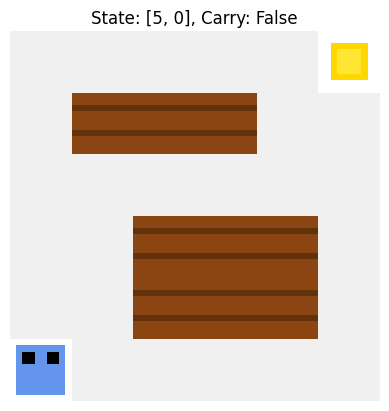

Step 1
Action: Right
State: (5, 1, 0) | Reward: -1


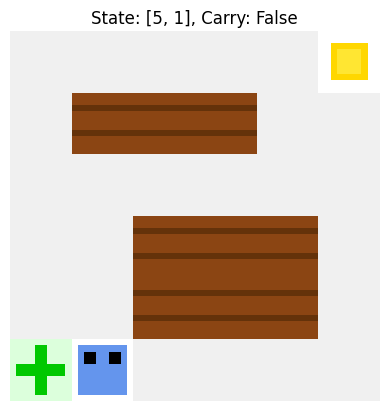

Step 2
Action: Pick
State: (5, 1, 0) | Reward: -6


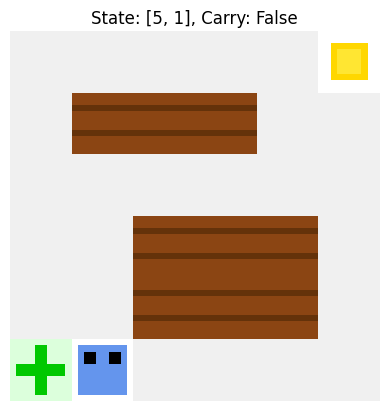

Step 3
Action: Left
State: (5, 0, 0) | Reward: -1


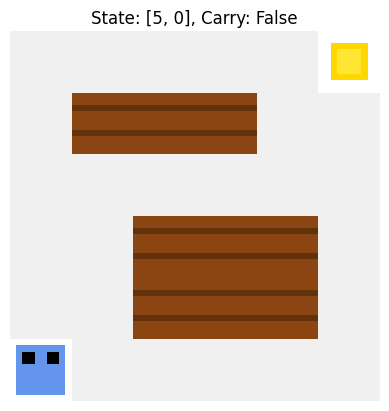

Step 4
Action: Pick
State: (5, 0, 0) | Reward: -6


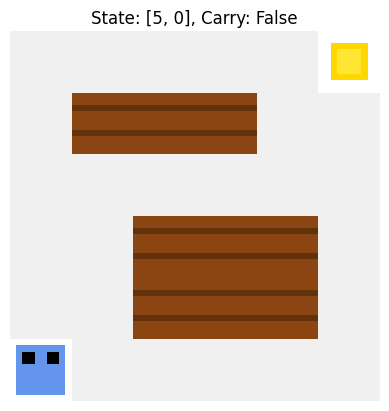

Step 5
Action: Right
State: (5, 1, 0) | Reward: -1


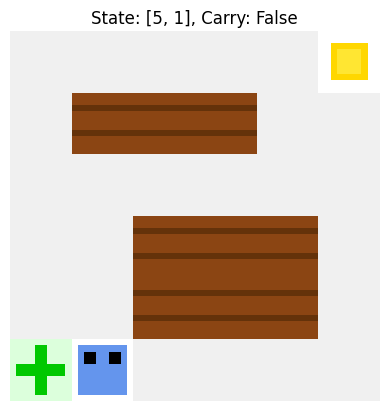

Step 6
Action: Left
State: (5, 0, 0) | Reward: -1


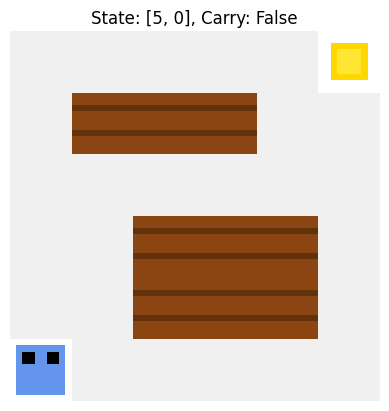

Step 7
Action: Down
State: (5, 0, 0) | Reward: -1


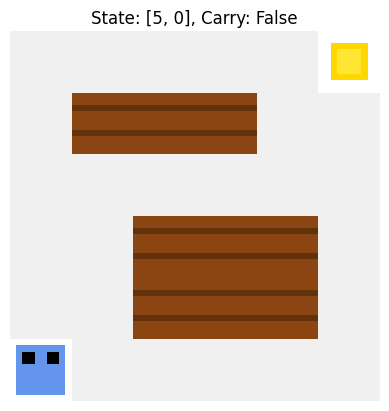

Step 8
Action: Down
State: (5, 0, 0) | Reward: -1


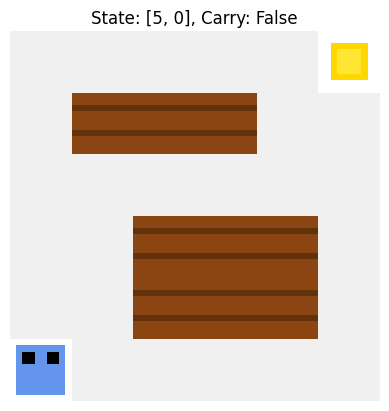

Step 9
Action: Right
State: (5, 1, 0) | Reward: -1


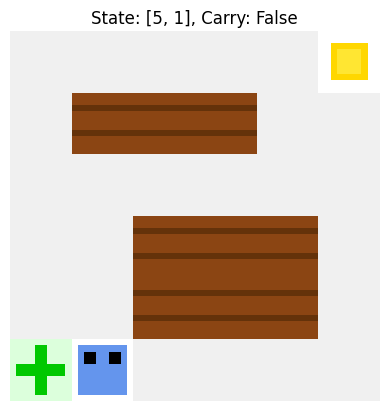

Step 10
Action: Down
State: (5, 1, 0) | Reward: -1


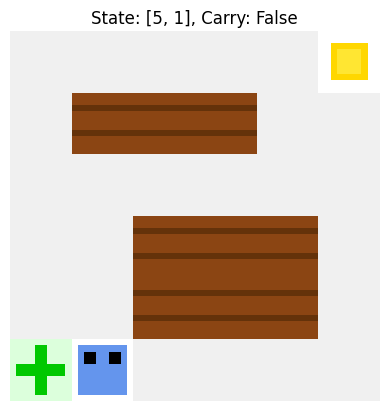

Step 11
Action: Pick
State: (5, 1, 0) | Reward: -6


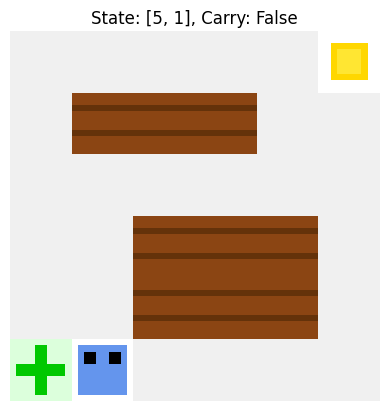

Step 12
Action: Down
State: (5, 1, 0) | Reward: -1


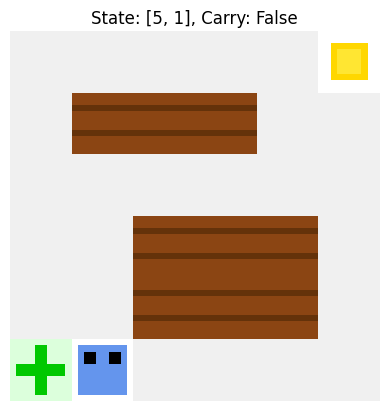

Step 13
Action: Right
State: (5, 2, 0) | Reward: -1


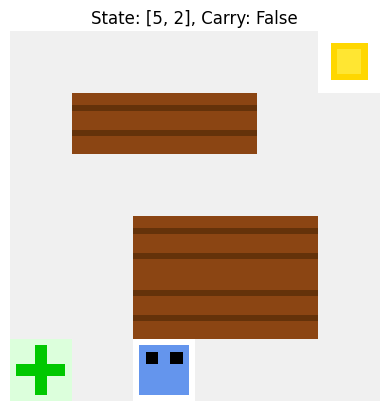

Step 14
Action: Right
State: (5, 3, 0) | Reward: -1


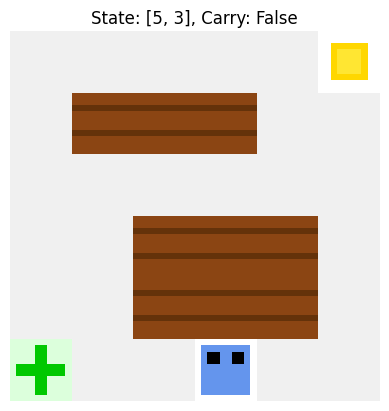

Step 15
Action: Right
State: (5, 4, 0) | Reward: -1


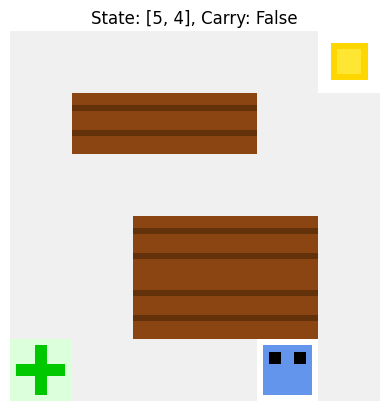

Step 16
Action: Drop
State: (5, 4, 0) | Reward: -6


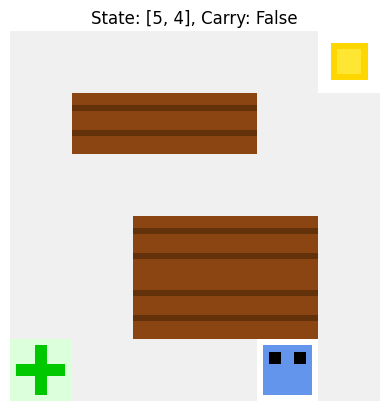

Step 17
Action: Drop
State: (5, 4, 0) | Reward: -6


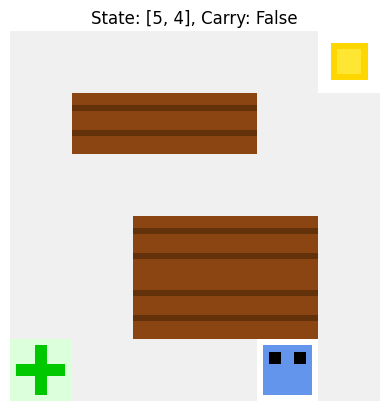

Step 18
Action: Up
State: (5, 4, 0) | Reward: -21


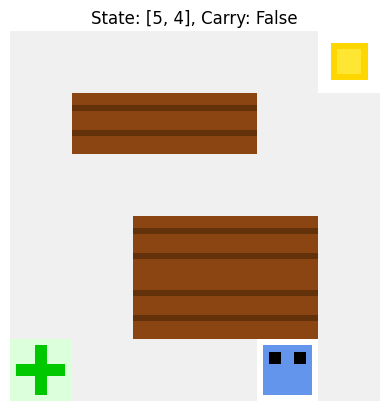

Step 19
Action: Up
State: (5, 4, 0) | Reward: -21


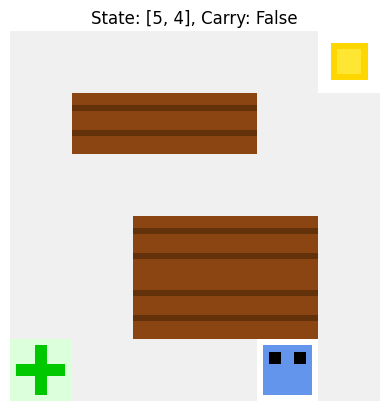

Step 20
Action: Left
State: (5, 3, 0) | Reward: -1


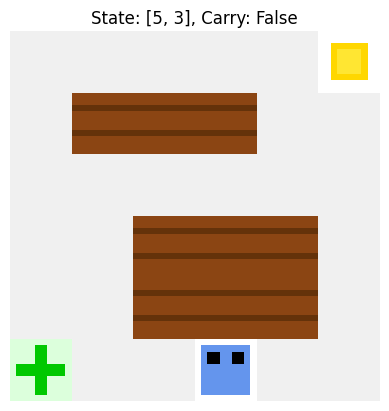

Step 21
Action: Pick
State: (5, 3, 0) | Reward: -6


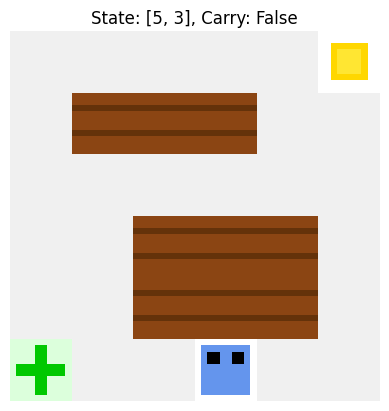

Step 22
Action: Left
State: (5, 2, 0) | Reward: -1


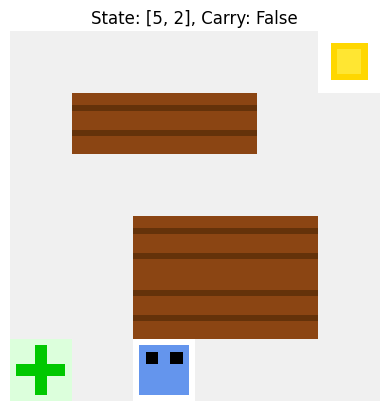

Step 23
Action: Left
State: (5, 1, 0) | Reward: -1


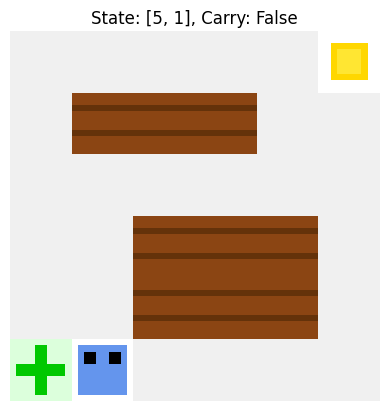

Step 24
Action: Right
State: (5, 2, 0) | Reward: -1


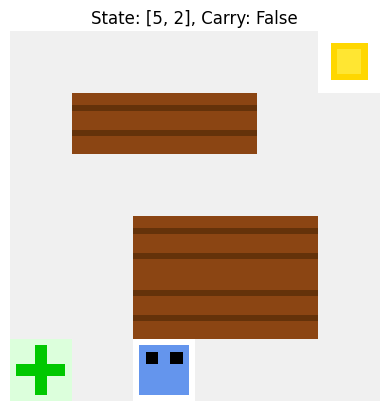

Step 25
Action: Drop
State: (5, 2, 0) | Reward: -6


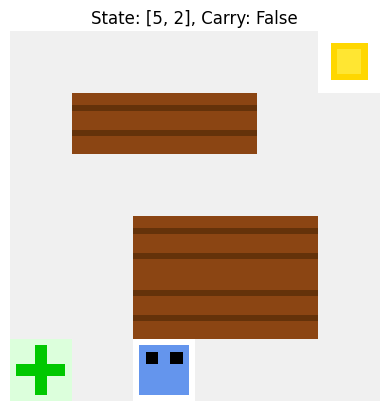

Step 26
Action: Up
State: (5, 2, 0) | Reward: -21


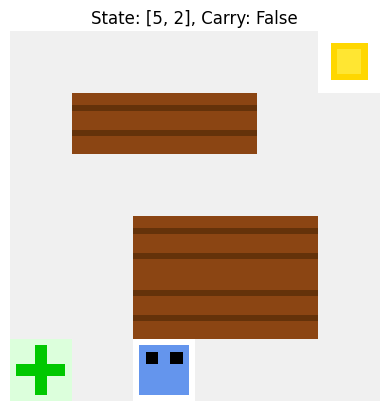

Step 27
Action: Left
State: (5, 1, 0) | Reward: -1


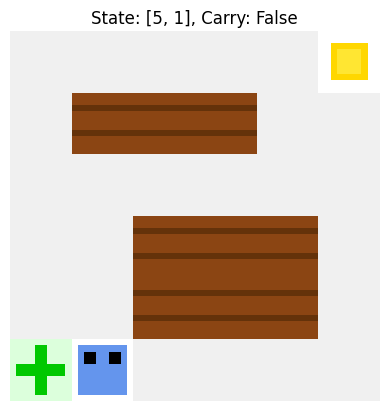

Step 28
Action: Down
State: (5, 1, 0) | Reward: -1


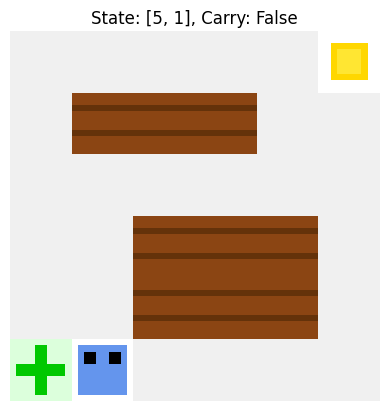

Step 29
Action: Down
State: (5, 1, 0) | Reward: -1


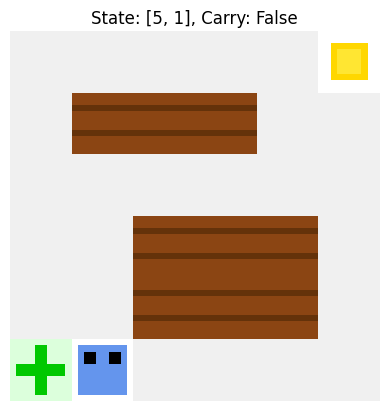

Step 30
Action: Pick
State: (5, 1, 0) | Reward: -6


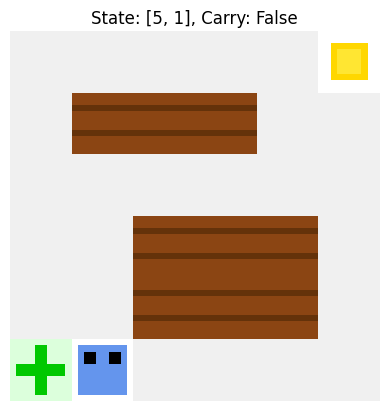

Step 31
Action: Pick
State: (5, 1, 0) | Reward: -6


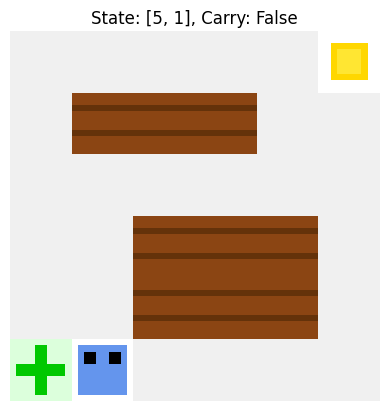

Step 32
Action: Right
State: (5, 2, 0) | Reward: -1


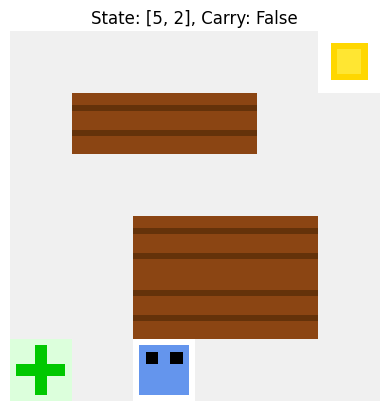

Step 33
Action: Pick
State: (5, 2, 0) | Reward: -6


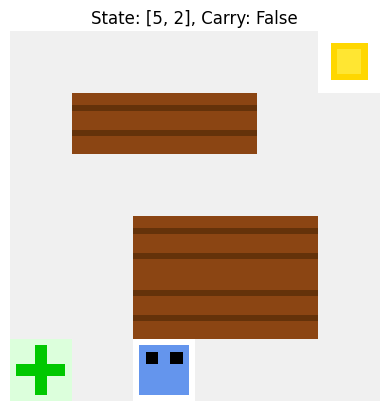

Step 34
Action: Right
State: (5, 3, 0) | Reward: -1


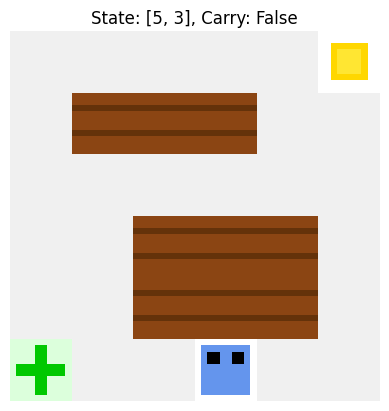

Step 35
Action: Up
State: (5, 3, 0) | Reward: -21


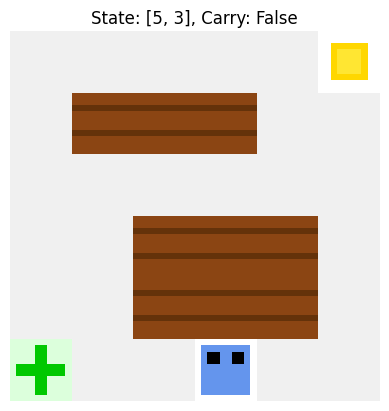

Step 36
Action: Drop
State: (5, 3, 0) | Reward: -6


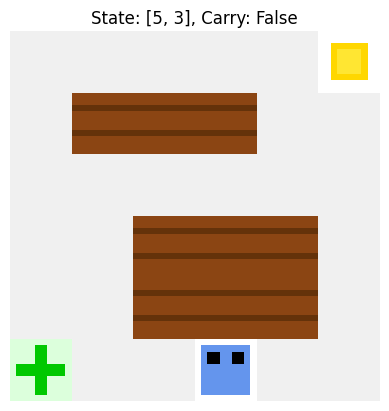

Step 37
Action: Up
State: (5, 3, 0) | Reward: -21


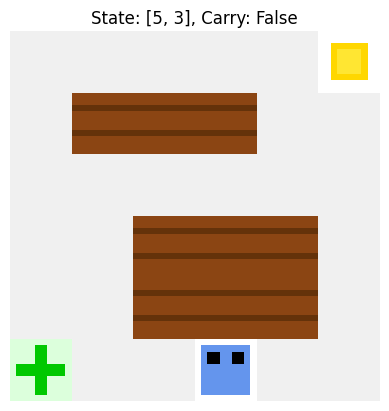

Step 38
Action: Up
State: (5, 3, 0) | Reward: -21


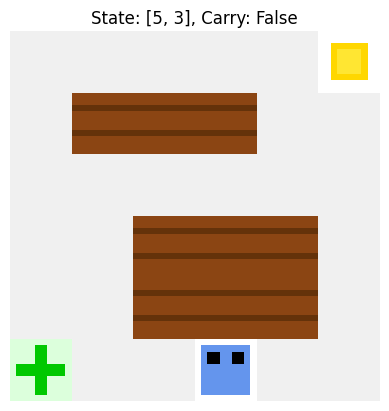

Step 39
Action: Up
State: (5, 3, 0) | Reward: -21


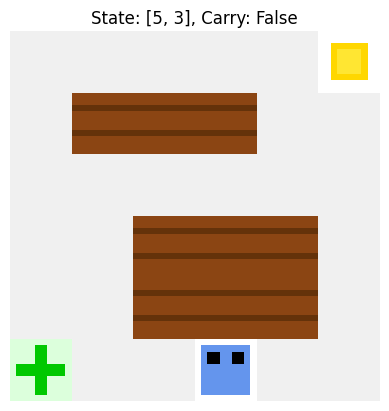

Step 40
Action: Pick
State: (5, 3, 0) | Reward: -6


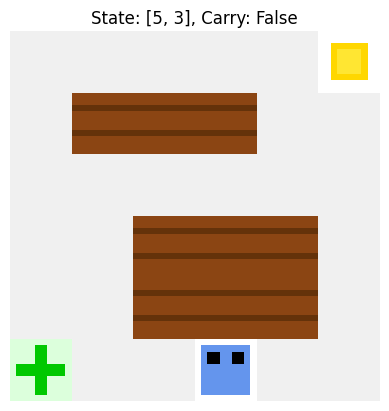

In [ ]:

env = WarehouseEnv()
obs, _ = env.reset(seed=42)
print("Start State:", obs)
env.render()

actions_map = {0:'Up', 1:'Down', 2:'Left', 3:'Right', 4:'Pick', 5:'Drop'}

for t in range(40):
    action = env.action_space.sample()
    obs, reward, done, truncated, _ = env.step(action)

    print(f"Step {t+1}")
    print(f"Action: {actions_map[action]}")
    print(f"State: {obs} | Reward: {reward}")
    env.render()

    if done:
        print("Goal Reached!")
        break

SARSA Implementation & Training

In [ ]:

def sarsa_warehouse(env, episodes=20000, alpha=0.1, gamma=0.99, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.999):

    q_table = np.zeros((env.grid_size, env.grid_size, 2, env.action_space.n))

    rewards_per_episode = []
    epsilon_history = []

    for ep in range(episodes):
        obs, _ = env.reset()
        r, c, carry = obs


        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[r, c, carry, :])

        total_reward = 0
        done = False

        while not done:

            next_obs, reward, terminated, truncated, _ = env.step(action)
            nr, nc, ncarry = next_obs
            done = terminated or truncated


            if np.random.rand() < epsilon:
                next_action = env.action_space.sample()
            else:
                next_action = np.argmax(q_table[nr, nc, ncarry, :])


            #Q(S, A) = Q(S, A) + alpha * [R + gamma * Q(S', A') - Q(S, A)]
            current_q = q_table[r, c, carry, action]
            next_q = q_table[nr, nc, ncarry, next_action] if not done else 0

            q_table[r, c, carry, action] += alpha * (reward + gamma * next_q - current_q)


            r, c, carry = nr, nc, ncarry
            action = next_action
            total_reward += reward


        if epsilon > epsilon_min:
            epsilon *= epsilon_decay

        rewards_per_episode.append(total_reward)
        epsilon_history.append(epsilon)

        if (ep+1) % 500 == 0:
            print(f"Episode {ep+1}: Total Reward: {total_reward}, Epsilon: {epsilon:.3f}")

    return q_table, rewards_per_episode, epsilon_history





SARSA results

In [ ]:

trained_q, rewards, epsilons = sarsa_warehouse(env, episodes=30000)

Episode 500: Total Reward: -8, Epsilon: 0.606
Episode 1000: Total Reward: 72, Epsilon: 0.368
Episode 1500: Total Reward: 86, Epsilon: 0.223
Episode 2000: Total Reward: 92, Epsilon: 0.135
Episode 2500: Total Reward: 100, Epsilon: 0.082
Episode 3000: Total Reward: 104, Epsilon: 0.050
Episode 3500: Total Reward: 100, Epsilon: 0.030
Episode 4000: Total Reward: 112, Epsilon: 0.018
Episode 4500: Total Reward: 108, Epsilon: 0.011
Episode 5000: Total Reward: 105, Epsilon: 0.010
Episode 5500: Total Reward: 110, Epsilon: 0.010
Episode 6000: Total Reward: 109, Epsilon: 0.010
Episode 6500: Total Reward: 104, Epsilon: 0.010
Episode 7000: Total Reward: 109, Epsilon: 0.010
Episode 7500: Total Reward: 113, Epsilon: 0.010
Episode 8000: Total Reward: 113, Epsilon: 0.010
Episode 8500: Total Reward: 109, Epsilon: 0.010
Episode 9000: Total Reward: 105, Epsilon: 0.010
Episode 9500: Total Reward: 106, Epsilon: 0.010
Episode 10000: Total Reward: 111, Epsilon: 0.010
Episode 10500: Total Reward: 111, Epsilon: 0

Q table before and after

In [ ]:


np.set_printoptions(threshold=np.inf, linewidth=np.inf)

#Initial Q-Table
initial_q = np.zeros((env.grid_size, env.grid_size, 2, env.action_space.n))
print("="*80)
print("initial Q table")
print("="*80)
print(initial_q)

#Trained Q-Table
print("\n" + "="*80)
print("trained Q table")
print("---"*80)
print(trained_q)

#resetting
np.set_printoptions(threshold=1000, linewidth=75)

initial Q table
[[[[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]]


 [[[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]]


 [[[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]]


 [[[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0.

In [ ]:


#Initial Q table
initial_q = np.zeros((env.grid_size, env.grid_size, 2, env.action_space.n))
#not carrying
print("Initial Q-table sample state: (3, 3)")
print(f"Index (3, 3, 0): {initial_q[3, 3, 0, :]}")
print(" Actions: [Up, Down, Left, Right, Pick, Drop]")
print("*-*-*" * 50)


actions_map = {0:'Up', 1:'Down', 2:'Left', 3:'Right', 4:'Pick', 5:'Drop'}

#Sample 1:state where the robot is not carrying the item (index 0)
sample_state_not_carrying = (5, 5, 0)
r, c, carry = sample_state_not_carrying
best_action_index = np.argmax(trained_q[r, c, carry, :])

print(f"Trained")
print(f"State: {sample_state_not_carrying} (not carrying)")
print(f"Q values: {trained_q[r, c, carry, :]}")
print(f"Greedy action: {actions_map[best_action_index]} (Index {best_action_index})")
print("****" * 50)

#Sample 2:state where the robot is carrying the item(index 1)
sample_state_carrying = (3, 3, 1)
r, c, carry = sample_state_carrying
best_action_index = np.argmax(trained_q[r, c, carry, :])

print(f"State: {sample_state_carrying} (carrying)")
print(f"Q values: {trained_q[r, c, carry, :]}")
print(f"Greedy action: {actions_map[best_action_index]} (Index {best_action_index})")
print("==" * 50)

Initial Q-table sample state: (3, 3)
Index (3, 3, 0): [0. 0. 0. 0. 0. 0.]
 Actions: [Up, Down, Left, Right, Pick, Drop]
*-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-**-*-*
Trained
State: (5, 5, 0) (not carrying)
Q values: [91.52729337 75.48577056 48.83974576 71.59143591 65.97686011 70.90236924]
Greedy action: Up (Index 0)
********************************************************************************************************************************************************************************************************
State: (3, 3, 1) (carrying)
Q values: [0. 0. 0. 0. 0. 0.]
Greedy action: Up (Index 0)


Evaluation and Plotting

Text(0, 0.5, 'Reward')

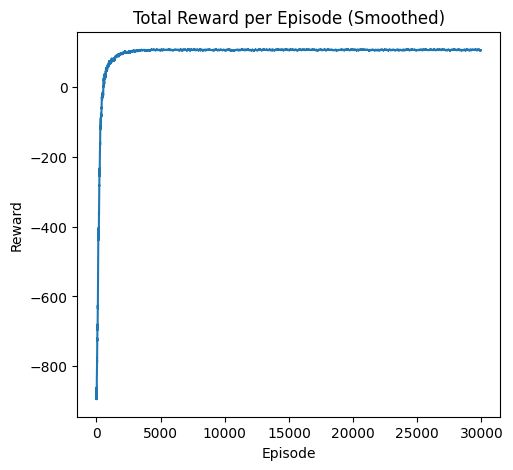

In [ ]:
# 1. Plot Rewards
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
window = 50
smoothed_rewards = np.convolve(rewards, np.ones(window)/window, mode='valid')
plt.plot(smoothed_rewards)
plt.title("Total Reward per Episode (Smoothed)")
plt.xlabel("Episode")
plt.ylabel("Reward")

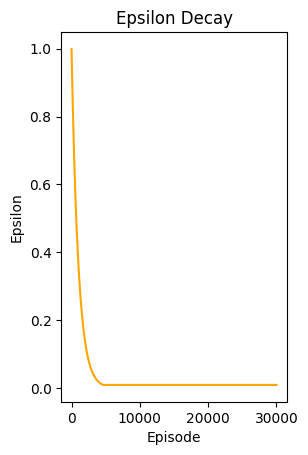

In [ ]:

#Epsilon decay
plt.subplot(1, 2, 2)
plt.plot(epsilons, color='orange')
plt.title("Epsilon Decay")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.show()

Greedy policy 50 episode

In [ ]:



greedy_rewards = []

for ep in range(50):
    obs, _ = env.reset()
    r, c, carry = obs
    total_r = 0
    done = False
    step_count = 0

    print(f"Episode {ep+1}: Start {obs}", end="")

    while not done:

        action = np.argmax(trained_q[r, c, carry, :])

        next_obs, reward, terminated, truncated, _ = env.step(action)
        r, c, carry = next_obs
        total_r += reward
        step_count += 1
        done = terminated or truncated

    greedy_rewards.append(total_r)
    print(f" Steps: {step_count} and  Reward: {total_r}")



Episode 1: Start (4, 0, 0) Steps: 21 and  Reward: 104
Episode 2: Start (5, 5, 0) Steps: 17 and  Reward: 108
Episode 3: Start (2, 2, 0) Steps: 17 and  Reward: 108
Episode 4: Start (2, 0, 0) Steps: 19 and  Reward: 106
Episode 5: Start (3, 0, 0) Steps: 20 and  Reward: 105
Episode 6: Start (0, 2, 0) Steps: 15 and  Reward: 110
Episode 7: Start (1, 4, 0) Steps: 14 and  Reward: 111
Episode 8: Start (5, 1, 0) Steps: 21 and  Reward: 104
Episode 9: Start (4, 1, 0) Steps: 22 and  Reward: 103
Episode 10: Start (5, 5, 0) Steps: 17 and  Reward: 108
Episode 11: Start (0, 3, 0) Steps: 14 and  Reward: 111
Episode 12: Start (0, 3, 0) Steps: 14 and  Reward: 111
Episode 13: Start (2, 5, 0) Steps: 14 and  Reward: 111
Episode 14: Start (4, 5, 0) Steps: 16 and  Reward: 109
Episode 15: Start (3, 1, 0) Steps: 19 and  Reward: 106
Episode 16: Start (5, 1, 0) Steps: 21 and  Reward: 104
Episode 17: Start (2, 4, 0) Steps: 15 and  Reward: 110
Episode 18: Start (5, 1, 0) Steps: 21 and  Reward: 104
Episode 19: Start (

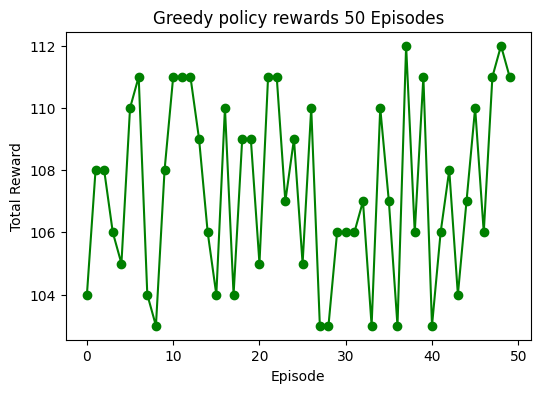

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(greedy_rewards, marker='o', linestyle='-', color='green')
plt.title("Greedy policy rewards 50 Episodes")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()